# Artifact Diagnosis Notebook
**Goal:** Understand the spatial/spectral nature of the artifact seen in CD31 (and other marker channels)
that the current tophat pipeline fails to catch — specifically the halo structure that causes tophat to either
miss it or ring-suppress real signal alongside it.

## Workflow
1. Load a single slice from the registered volume
2. **Crop to the artifact region** — zoomed-in spatial inspection
3. **Intensity profile analysis** — radial profiles to characterize the halo
4. **Multi-channel co-localization** — see which channels share the artifact
5. **Tophat SE sweep** — why tophat fails for halos
6. **Alternative detection strategies** — rank-order filter, DoG, SSIM anomaly, local-z-score
7. **Interactive artifact picker** — click artifacts, get radial stats automatically

In [22]:
import os, sys, warnings
import numpy as np
import zarr
import tifffile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.widgets import RectangleSelector
from matplotlib.gridspec import GridSpec
import cv2
from scipy import ndimage as ndi
from scipy.ndimage import uniform_filter, generic_filter
from scipy.signal import correlate2d
from skimage.morphology import white_tophat, disk, black_tophat
from skimage.filters import threshold_otsu, difference_of_gaussians
from skimage.measure import label, regionprops
from skimage.draw import disk as draw_disk

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))
import config

print('Environment ready.')

def stretch(img, lo_pct=1, hi_pct=99.5):
    tissue = img[img > 0]
    if tissue.size == 0:
        return img
    lo, hi = np.percentile(tissue, [lo_pct, hi_pct])
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0, 1)

print('Environment ready.')


Environment ready.
Environment ready.


In [23]:
# ─────────────────────────────────────────────────────────────────
# CONFIG — edit these
# ─────────────────────────────────────────────────────────────────
TARGET_CORE   = 'Core_02'
SLICE_Z       = 19          # Z-slice that shows the artifact
PIXEL_UM      = 0.4961      # µm per pixel (must match your acquisition)

CHANNEL_NAMES = ['DAPI', 'CD31', 'GAP43', 'NFP', 'CD3', 'CD163', 'CK', 'AF']

# ── QuPath coordinate input (preferred) ──────────────────────────
# Copy the µm coordinates directly from QuPath's status bar or annotation.
# QuPath reports (x=col, y=row) in microns from the TOP-LEFT of the WHOLE
# SLIDE IMAGE — NOT from the core crop. The cell below converts these to
# local pixel coordinates inside the registered volume automatically.
# Set both to None to fall back to auto-detection.
QUPATH_X_UM   = None      
QUPATH_Y_UM   = None      

# ── Manual override (local volume pixels, 0-indexed) ─────────────
# If you already know the pixel position inside the cropped volume,
# set ARTIFACT_RC = (row, col) here and it takes priority over QuPath.
ARTIFACT_RC   = None        # e.g. (512, 300)

# Crop half-width around the artifact for zoomed panels (pixels)
CROP_HALF     = 150

VOL_PATH = os.path.join(
    config.DATASPACE,
    'Filter_AKAZE_RoMaV2_Linear_Warp_map',
    TARGET_CORE,
    f'{TARGET_CORE}_AKAZE_RoMaV2_Linear_Aligned.ome.tif',
)

print(f'Volume path: {VOL_PATH}')
print(f'Exists     : {os.path.exists(VOL_PATH)}')


Volume path: /data3/junming/3D-TMA-Register/Filter_AKAZE_RoMaV2_Linear_Warp_map/Core_02/Core_02_AKAZE_RoMaV2_Linear_Aligned.ome.tif
Exists     : True


In [24]:
# ─────────────────────────────────────────────────────────────────
# 1. LOAD ONE SLICE (lazy)
# ─────────────────────────────────────────────────────────────────
with tifffile.TiffFile(VOL_PATH) as tif:
    z_arr = zarr.open(tif.aszarr(), mode='r')
    print(f'Volume shape: {z_arr.shape}')   # expected ZCYX
    N_CH = z_arr.shape[1]
    chans = [z_arr[SLICE_Z, c].astype(np.float32) for c in range(N_CH)]

H, W = chans[0].shape
print(f'Slice shape : {H} x {W}   ({H*PIXEL_UM:.0f} x {W*PIXEL_UM:.0f} µm)')
print(f'Channels    : {N_CH}')

Volume shape: (20, 8, 6112, 6112)
Slice shape : 6112 x 6112   (3032 x 3032 µm)
Channels    : 8


In [25]:
# ─────────────────────────────────────────────────────────────────
# 2. COORDINATE RESOLUTION
# ─────────────────────────────────────────────────────────────────
# Priority order:
#   1. ARTIFACT_RC (manual local-pixel override) — used as-is
#   2. QUPATH_X_UM / QUPATH_Y_UM — converted to local volume pixels
#      by reading the crop origin from the OME-TIFF metadata
#   3. Auto-detect from CD31 intensity (fallback)
#
# WHY QUPATH COORDS DON'T MATCH DIRECTLY:
#   QuPath µm are measured from the top-left of the whole slide image.
#   Your registered volume is a cropped TMA core — its pixel (0,0) is
#   NOT the WSI origin. To convert, we need the crop's physical offset,
#   stored in the OME-TIFF as the Plane StageX/StageY, or in the
#   XPosition/YPosition TIFF tags (286/287), or as OME-XML attributes.

CD31_IDX = CHANNEL_NAMES.index('CD31') if 'CD31' in CHANNEL_NAMES else 1
cd31 = chans[CD31_IDX]

def read_crop_origin_um(vol_path):
    """
    Try to read the physical (x, y) offset of the cropped volume
    relative to the whole-slide image, in micrometres.
    Returns (origin_x_um, origin_y_um) or (None, None) if not found.

    Checks (in order):
      1. OME-XML Plane StageX / StageY attributes
      2. TIFF tags 286 (XPosition) and 287 (YPosition)
      3. tifffile series.axes / series.sizes offset metadata
    """
    try:
        with tifffile.TiffFile(vol_path) as tif:
            # ── Try OME-XML first (most reliable for OME-TIFF) ────────────
            if tif.ome_metadata:
                import xml.etree.ElementTree as ET
                ns = {'ome': 'http://www.openmicroscopy.org/Schemas/OME/2016-06'}
                root = ET.fromstring(tif.ome_metadata)
                # Look for StageX/StageY in any Plane element
                for plane in root.findall('.//ome:Plane', ns):
                    sx = plane.get('StageX')
                    sy = plane.get('StageY')
                    if sx is not None and sy is not None:
                        return float(sx), float(sy)
                # Fallback: PhysicalSizeX/Y + position on Pixels element
                for pixels in root.findall('.//ome:Pixels', ns):
                    px = pixels.get('PhysicalSizeX')
                    py = pixels.get('PhysicalSizeY')
                    if px and py:
                        # no position embedded — return None to try TIFF tags
                        break

            # ── Try TIFF tags 286/287 (XPosition / YPosition) ─────────────
            # These are stored as RATIONAL (numerator/denominator pairs)
            # in units of the ResolutionUnit (usually inches → convert to µm)
            page = tif.pages[0]
            tags = page.tags

            # ResolutionUnit: 1=no unit, 2=inch, 3=centimetre
            res_unit = tags.get(296)  # tag 296 = ResolutionUnit
            x_res    = tags.get(282)  # tag 282 = XResolution (px per unit)
            y_res    = tags.get(283)  # tag 283 = YResolution
            x_pos    = tags.get(286)  # tag 286 = XPosition (pos in unit)
            y_pos    = tags.get(287)  # tag 287 = YPosition

            if x_pos is not None and y_pos is not None:
                unit = res_unit.value if res_unit else 2  # default inches
                xp   = x_pos.value[0] / x_pos.value[1] if isinstance(x_pos.value, tuple) else float(x_pos.value)
                yp   = y_pos.value[0] / y_pos.value[1] if isinstance(y_pos.value, tuple) else float(y_pos.value)
                xr   = x_res.value[0] / x_res.value[1] if (x_res and isinstance(x_res.value, tuple)) else None
                yr   = y_res.value[0] / y_res.value[1] if (y_res and isinstance(y_res.value, tuple)) else None
                if xr and yr:
                    # Position is in units (inches or cm), XResolution = px/unit
                    # → position in pixels = xp * xr
                    # → position in µm = pixels * PIXEL_UM
                    x_um = (xp * xr) * PIXEL_UM
                    y_um = (yp * yr) * PIXEL_UM
                    return x_um, y_um
                elif unit == 3:   # centimetres — xp already in cm
                    return xp * 1e4, yp * 1e4
                else:             # inches
                    return xp * 25400, yp * 25400
    except Exception as e:
        print(f'  metadata read warning: {e}')
    return None, None


def qupath_um_to_local_px(qx_um, qy_um, vol_path, pixel_um):
    """
    Convert QuPath whole-slide µm coords to local pixel coords in the
    cropped volume. Returns (local_row, local_col) as integers.
    """
    origin_x_um, origin_y_um = read_crop_origin_um(vol_path)

    if origin_x_um is not None:
        local_col = int(round((qx_um - origin_x_um) / pixel_um))
        local_row = int(round((qy_um - origin_y_um) / pixel_um))
        print(f'  Crop origin from metadata: x={origin_x_um:.1f}µm, y={origin_y_um:.1f}µm')
        print(f'  QuPath → local px: row={local_row}, col={local_col}')
        return local_row, local_col
    else:
        print('  WARNING: Could not read crop origin from OME-TIFF metadata.')
        print('  Falling back to: assuming QuPath coords are already local.')
        print('  This will be wrong if the volume is a sub-crop of the WSI!')
        print()
        print('  To fix, check these alternative sources for the crop origin:')
        print('    a) registration_stats_AKAZE_RoMaV2_Linear.csv — look for')
        print('       columns like CoreX_um, CoreY_um, OffsetX, OffsetY')
        print('    b) Your TMA dearraying output (e.g. core_coordinates.csv)')
        print('    c) Set ARTIFACT_RC manually using the pixel coords below')
        # Best-effort: treat QuPath coords as if they were local-pixel µm
        local_col = int(round(qx_um / pixel_um))
        local_row = int(round(qy_um / pixel_um))
        print(f'  Naive conversion (likely wrong): row={local_row}, col={local_col}')
        return local_row, local_col



def autodetect_artifact_blob(img, top_n=5, min_sep_px=80):
    """
    Auto-detects the artifact by searching for small, compact blobs 
    rather than raw pixel intensity, using a Difference of Gaussians (DoG).
    """
    import cv2
    import numpy as np
    
    # 1. Convert to float to avoid uint8 overflow during math operations
    img_f = img.astype(np.float32)
    
    # 2. Apply DoG: Subtract a heavily blurred image from a lightly blurred one.
    # This acts as a spatial bandpass filter: it suppresses large bright 
    # vessels/tissue and aggressively highlights small, dot-like peaks.
    blur_small = cv2.GaussianBlur(img_f, (5, 5), 0)
    blur_large = cv2.GaussianBlur(img_f, (31, 31), 0)
    
    blob_map = blur_small - blur_large
    blob_map[blob_map < 0] = 0  # Ignore dark spots
    
    # 3. Suppress image borders heavily to ignore registration edge artifacts
    margin = 100
    blob_map[:margin, :] = 0; blob_map[-margin:, :] = 0
    blob_map[:, :margin] = 0; blob_map[:, -margin:] = 0
    
    candidates = []
    search_img = blob_map.copy()
    
    for _ in range(top_n):
        # Find the maximum blob-response score
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(search_img)
        bc, br = max_loc 
        
        # If the highest remaining blob response is noise, stop searching
        if max_val < 5.0:
            break
            
        candidates.append((br, bc))
        
        # Zero out a radius around this peak to find the next discrete blob
        cv2.circle(search_img, (bc, br), min_sep_px, 0, -1)
        
    if not candidates:
        return [(img.shape[0]//2, img.shape[1]//2)]
        
    return candidates

# ── Resolve the artifact centre ───────────────────────────────────
print('Resolving artifact centre...')

if ARTIFACT_RC is not None:
    ar, ac = ARTIFACT_RC
    print(f'  Using manual override: row={ar}, col={ac}')

elif QUPATH_X_UM is not None and QUPATH_Y_UM is not None:
    print(f'  QuPath input: x={QUPATH_X_UM}µm, y={QUPATH_Y_UM}µm')
    ar, ac = qupath_um_to_local_px(QUPATH_X_UM, QUPATH_Y_UM, VOL_PATH, PIXEL_UM)
    # Clamp to valid range
    ar = max(CROP_HALF, min(H - CROP_HALF, ar))
    ac = max(CROP_HALF, min(W - CROP_HALF, ac))
    print(f'  Clamped to image bounds: row={ar}, col={ac}')

else:
    print('  No coordinates provided — auto-detecting from CD31...')
    candidates = autodetect_artifact_blob(cd31)
    ar, ac = candidates[0]
    print(f'  Auto-detected: row={ar}, col={ac}')

print(f'\nFinal centre: row={ar}, col={ac}')

# ── Set crop bounds ───────────────────────────────────────────────
r0 = max(0, ar - CROP_HALF);  r1 = min(H, ar + CROP_HALF)
c0 = max(0, ac - CROP_HALF);  c1 = min(W, ac + CROP_HALF)
print(f'\nCrop region: rows {r0}–{r1}, cols {c0}–{c1}')


Resolving artifact centre...
  No coordinates provided — auto-detecting from CD31...
  Auto-detected: row=5401, col=1478

Final centre: row=5401, col=1478

Crop region: rows 5251–5551, cols 1328–1628


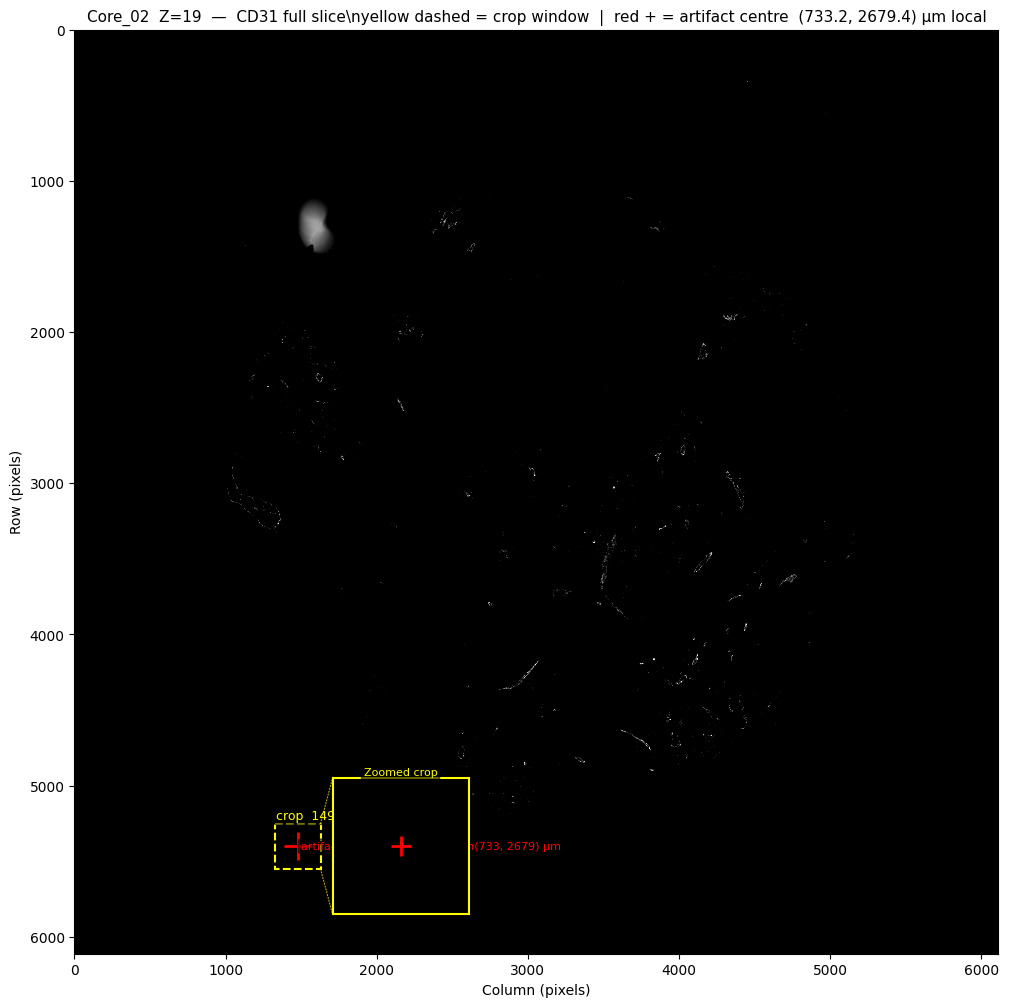

Full slice      : 6112 × 6112 px  (3.03 × 3.03 mm)
Artifact centre : row=5401, col=1478  →  (733.2, 2679.4) µm local
Crop window     : rows 5251–5551, cols 1328–1628  (149 × 149 µm)
CD31 at centre  : 1377  (crop peak: 1377,  full-slice peak: 1623)

OK: centre intensity is close to crop peak — crosshair looks correct.


In [26]:
# ─────────────────────────────────────────────────────────────────
# 2b. FULL-SLICE OVERVIEW — crop region and artifact location
# ─────────────────────────────────────────────────────────────────

fig, ax_main = plt.subplots(1, 1, figsize=(12, 12))

ax_main.imshow(stretch(cd31, lo_pct=1, hi_pct=99.9),
               cmap='gray', interpolation='nearest',
               extent=[0, W, H, 0])   # explicit extent: x=col, y=row, origin top-left

# ── Crop rectangle ────────────────────────────────────────────────
rect = plt.Rectangle(
    (c0, r0), c1 - c0, r1 - r0,
    linewidth=1.5, edgecolor='yellow', facecolor='none', linestyle='--'
)
ax_main.add_patch(rect)

# ── Artifact centre crosshair ─────────────────────────────────────
# ax_main uses data coords = (col, row) after extent= is set
ax_main.plot(ac, ar, 'r+', markersize=20, markeredgewidth=2)

# Labels
ax_main.text(
    c0 + 4, r0 - 10,
    f'crop  {(c1-c0)*PIXEL_UM:.0f}×{(r1-r0)*PIXEL_UM:.0f} µm',
    color='yellow', fontsize=9, va='bottom',
    bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5)
)
ax_main.text(
    ac + 18, ar,
    f'artifact  row={ar} col={ac}\\n({ac*PIXEL_UM:.0f}, {ar*PIXEL_UM:.0f}) µm',
    color='red', fontsize=8, va='center',
    bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5)
)

ax_main.set_xlim(0, W)
ax_main.set_ylim(H, 0)   # imshow convention: row 0 at top
ax_main.set_xlabel('Column (pixels)')
ax_main.set_ylabel('Row (pixels)')
ax_main.set_title(
    f'{TARGET_CORE}  Z={SLICE_Z}  —  CD31 full slice\\n'
    f'yellow dashed = crop window  |  red + = artifact centre  '
    f'({ac*PIXEL_UM:.1f}, {ar*PIXEL_UM:.1f}) µm local',
    fontsize=11
)

# ── Inset: zoomed crop ────────────────────────────────────────────
# Place inset adjacent to the crop box, not in a fixed figure corner,
# so it doesn't overlap a different part of the tissue.
# Compute figure-fraction position from data coords.
fig.canvas.draw()   # needed to get ax_main transforms
trans = ax_main.transData + fig.transFigure.inverted()

# Convert crop box corners to figure fractions
left_fig,  top_fig    = trans.transform((c0, r0))
right_fig, bottom_fig = trans.transform((c1, r1))

crop_w_fig = right_fig - left_fig
crop_h_fig = bottom_fig - top_fig

# Place inset to the RIGHT of the crop box, same vertical centre,
# same height as the crop box, width proportional to crop aspect ratio
inset_w = min(crop_w_fig * 3.0, 0.30)   # 3× zoom but cap at 30% fig width
inset_h = inset_w * (r1 - r0) / (c1 - c0)
inset_x = min(right_fig + 0.01, 0.99 - inset_w)  # don't go off figure
inset_y = (top_fig + bottom_fig) / 2 - inset_h / 2
inset_y = max(0.01, min(0.99 - inset_h, inset_y))

ax_inset = fig.add_axes([inset_x, inset_y, inset_w, inset_h])
crop_disp = cd31[r0:r1, c0:c1]
ax_inset.imshow(stretch(crop_disp, lo_pct=1, hi_pct=99.9),
                cmap='gray', interpolation='nearest')
# Crosshair in inset pixel coords
ax_inset.plot(ac - c0, ar - r0, 'r+', markersize=14, markeredgewidth=2)
for spine in ax_inset.spines.values():
    spine.set_edgecolor('yellow'); spine.set_linewidth(1.5)
ax_inset.set_xticks([]); ax_inset.set_yticks([])
ax_inset.set_title('Zoomed crop', fontsize=8, color='yellow', pad=2,
                   bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))

# ── Connector lines from crop rect right edge to inset left edge ──
from matplotlib.patches import ConnectionPatch
for (rect_col, rect_row, inset_xf, inset_yf) in [
    (c1, r0, 0.0, 1.0),   # top-right of crop rect  → top-left    of inset
    (c1, r1, 0.0, 0.0),   # bottom-right of crop rect → bottom-left of inset
]:
    con = ConnectionPatch(
        xyA=(rect_col, rect_row), coordsA=ax_main.transData,
        xyB=(inset_xf, inset_yf), coordsB=ax_inset.transAxes,
        color='yellow', linewidth=0.8, linestyle=':', alpha=0.7
    )
    fig.add_artist(con)

plt.show()

# ── Summary ───────────────────────────────────────────────────────
print(f'Full slice      : {W} × {H} px  ({W*PIXEL_UM/1000:.2f} × {H*PIXEL_UM/1000:.2f} mm)')
print(f'Artifact centre : row={ar}, col={ac}  →  ({ac*PIXEL_UM:.1f}, {ar*PIXEL_UM:.1f}) µm local')
print(f'Crop window     : rows {r0}–{r1}, cols {c0}–{c1}  ({(c1-c0)*PIXEL_UM:.0f} × {(r1-r0)*PIXEL_UM:.0f} µm)')
print(f'CD31 at centre  : {cd31[ar, ac]:.0f}  (crop peak: {cd31[r0:r1,c0:c1].max():.0f},  full-slice peak: {cd31.max():.0f})')
print()
if cd31[ar, ac] < 0.5 * cd31[r0:r1, c0:c1].max():
    print('WARNING: intensity at resolved centre is much lower than crop peak.')
    print('         The crosshair may not be on the artifact core.')
    print('         → Set ARTIFACT_RC manually or check coordinate resolution output.')
else:
    print('OK: centre intensity is close to crop peak — crosshair looks correct.')

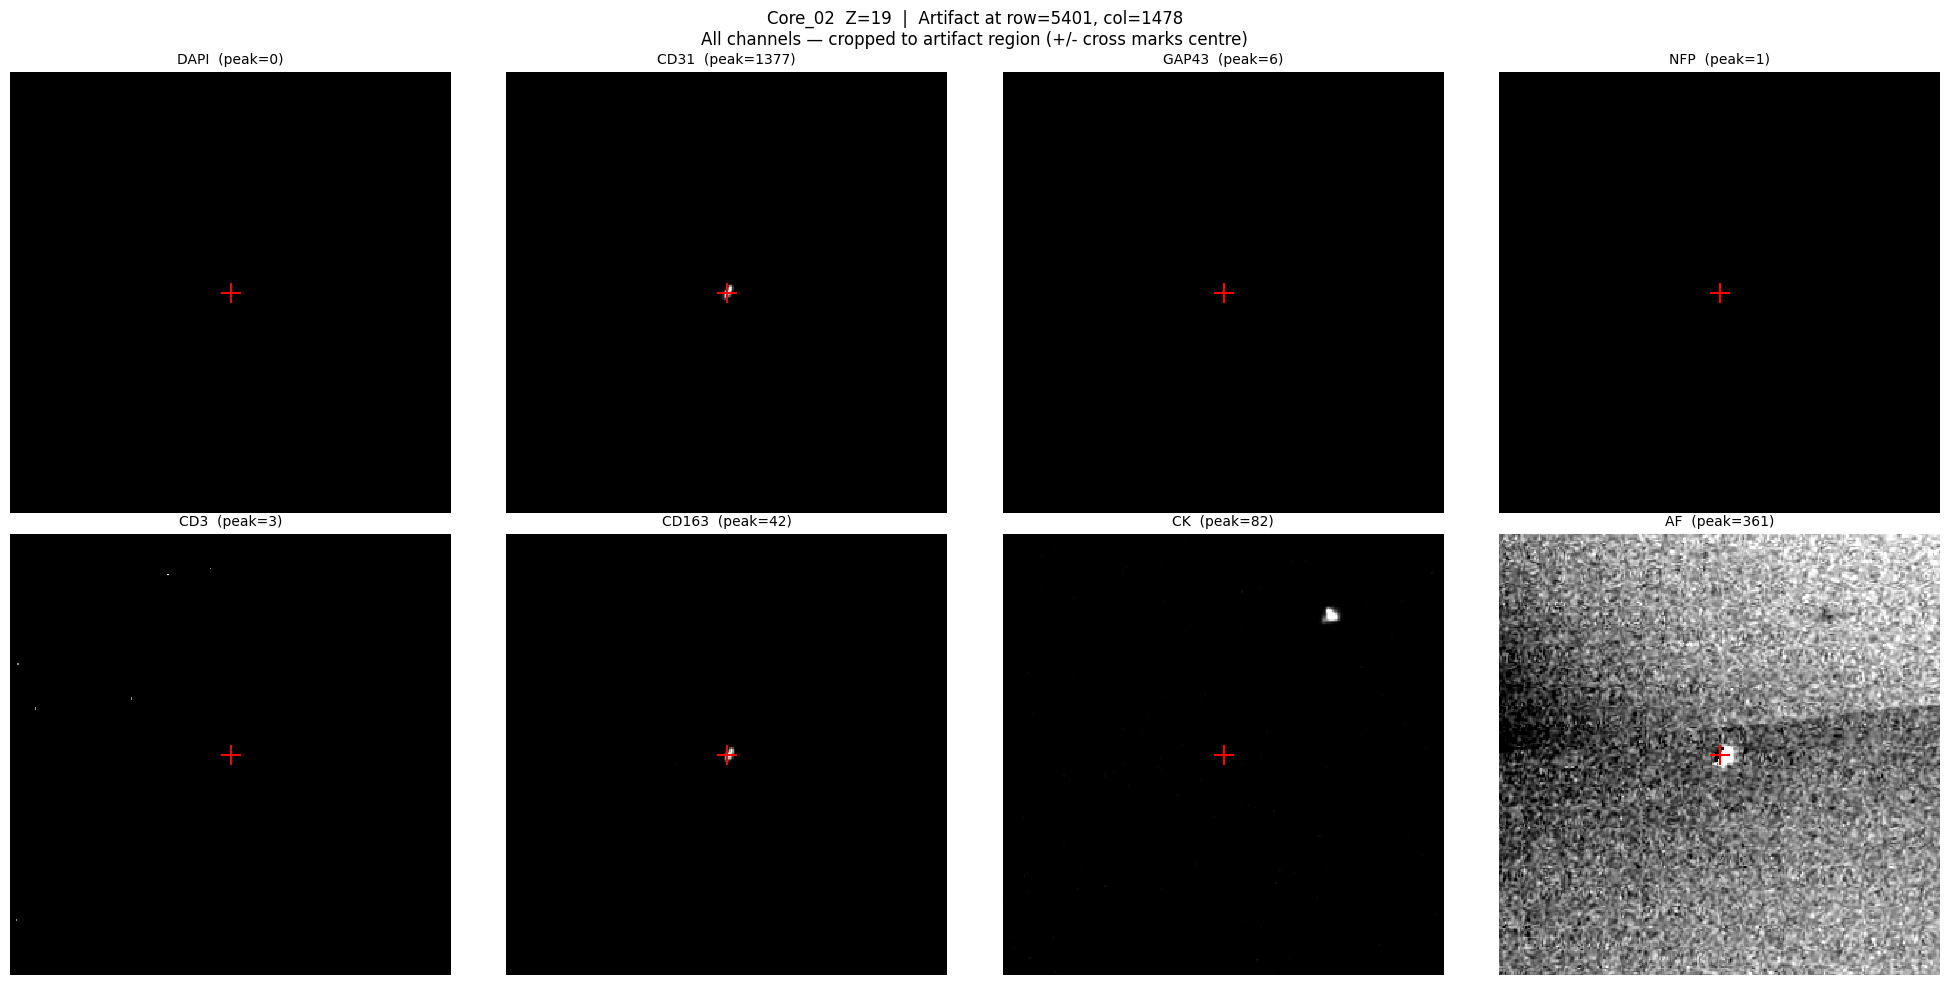

In [27]:
# ─────────────────────────────────────────────────────────────────
# 3. MULTI-CHANNEL OVERVIEW AT ARTIFACT LOCATION
# ─────────────────────────────────────────────────────────────────
# Shows all channels cropped around the artifact so you can see
# which channels co-localize and what the halo looks like per channel.

n_cols = 4
n_rows = int(np.ceil(N_CH / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for ci, img in enumerate(chans):
    crop = img[r0:r1, c0:c1]
    ax = axes[ci]
    ax.imshow(stretch(crop), cmap='gray', interpolation='nearest')
    ch_name = CHANNEL_NAMES[ci] if ci < len(CHANNEL_NAMES) else f'Ch{ci}'
    peak = crop.max()
    ax.set_title(f'{ch_name}  (peak={peak:.0f})', fontsize=10)
    # Mark artifact centre
    ax.plot(ac - c0, ar - r0, 'r+', markersize=14, markeredgewidth=1.5)
    ax.axis('off')

for i in range(N_CH, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    f'{TARGET_CORE}  Z={SLICE_Z}  |  Artifact at row={ar}, col={ac}\n'
    'All channels — cropped to artifact region (+/- cross marks centre)',
    fontsize=12
)
plt.tight_layout()
plt.show()

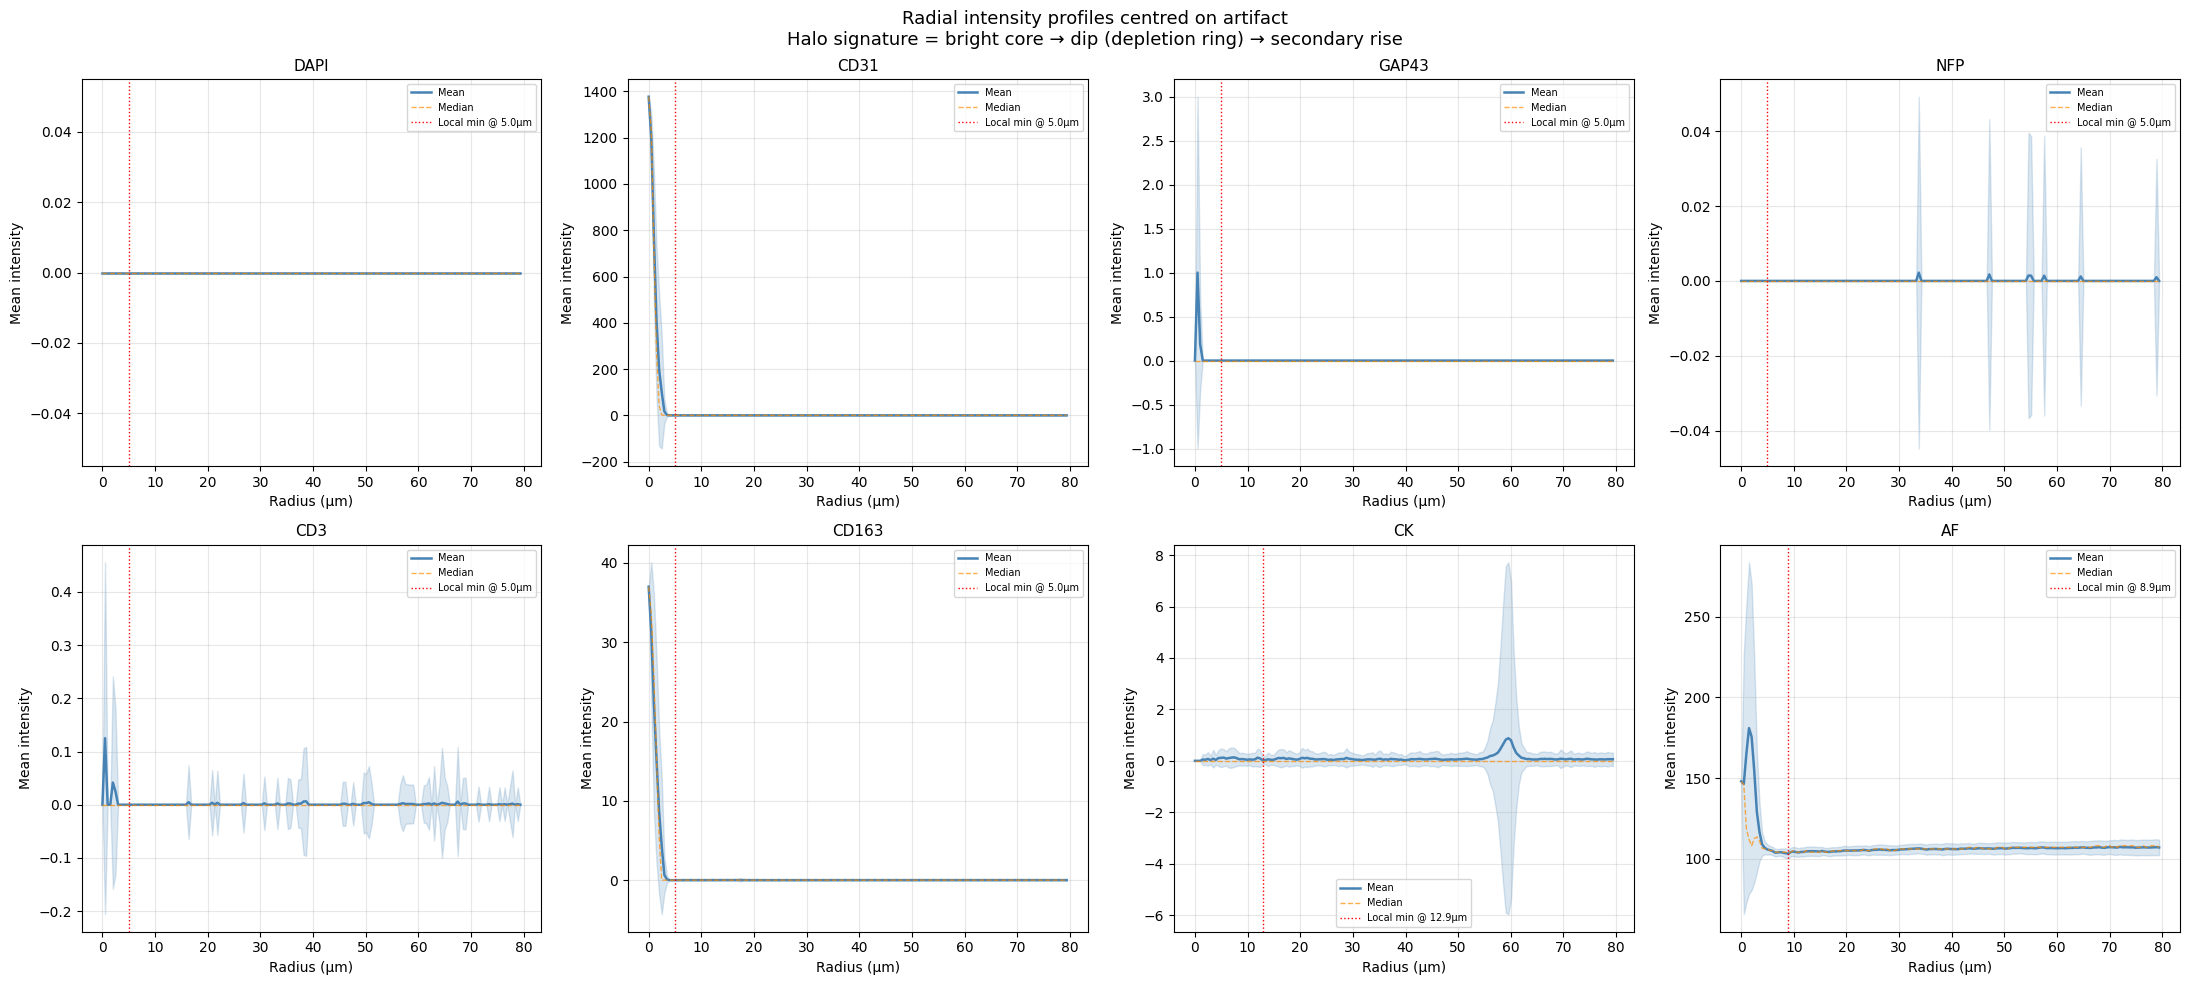

─── CD31 radial profile summary ───
  Core peak     : 1377.0  (radius 0)
  Depletion min : 0.0  at 5.0 µm
  Halo max      : 0.0  at 5.0 µm
  Core/bg ratio : 1377.0x above far background
  Halo/bg ratio : 0.0x above far background


In [28]:
# ─────────────────────────────────────────────────────────────────
# 4. RADIAL INTENSITY PROFILE — the key diagnostic
# ─────────────────────────────────────────────────────────────────
# A halo artifact = bright core + dark ring (depletion) + bright outer ring
# A simple dust spot = bright core + monotonic falloff
# This plot will show you which pattern you have, and at what radius
# the halo appears. That radius is critical for choosing the right SE size
# or switching to a different detection method.

def radial_profile(img, centre_r, centre_c, max_r=None):
    """Mean intensity as a function of distance from centre."""
    if max_r is None:
        max_r = min(centre_r, img.shape[0]-centre_r,
                    centre_c, img.shape[1]-centre_c) - 1
    max_r = int(max_r)
    radii = np.arange(0, max_r)
    means, stds, medians = [], [], []
    Y, X = np.ogrid[:img.shape[0], :img.shape[1]]
    dist = np.sqrt((Y - centre_r)**2 + (X - centre_c)**2)
    for r in radii:
        ring = img[(dist >= r) & (dist < r + 1)]
        means.append(ring.mean() if ring.size else 0)
        stds.append(ring.std() if ring.size else 0)
        medians.append(np.median(ring) if ring.size else 0)
    return np.array(radii), np.array(means), np.array(stds), np.array(medians)

MAX_RADIUS_UM = 80   # µm — adjust if artifact is larger
MAX_RADIUS_PX = int(MAX_RADIUS_UM / PIXEL_UM)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ci, img in enumerate(chans):
    radii, means, stds, meds = radial_profile(img, ar, ac, max_r=MAX_RADIUS_PX)
    ax = axes[ci]
    ch_name = CHANNEL_NAMES[ci] if ci < len(CHANNEL_NAMES) else f'Ch{ci}'
    
    radii_um = radii * PIXEL_UM
    ax.plot(radii_um, means, lw=1.8, color='steelblue', label='Mean')
    ax.fill_between(radii_um, means-stds, means+stds, alpha=0.2, color='steelblue')
    ax.plot(radii_um, meds, lw=1, ls='--', color='darkorange', alpha=0.7, label='Median')
    
    # Annotate minimum (the dark ring / depletion zone) if it exists
    if len(means) > 5:
        # Only look past the bright core (first 5µm)
        search_start = max(1, int(5 / PIXEL_UM))
        local_min_idx = search_start + np.argmin(means[search_start:])
        local_min_um  = local_min_idx * PIXEL_UM
        ax.axvline(local_min_um, color='red', ls=':', lw=1,
                   label=f'Local min @ {local_min_um:.1f}µm')
    
    ax.set_title(ch_name, fontsize=11)
    ax.set_xlabel('Radius (µm)')
    ax.set_ylabel('Mean intensity')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle(
    'Radial intensity profiles centred on artifact\n'
    'Halo signature = bright core → dip (depletion ring) → secondary rise',
    fontsize=13
)
plt.tight_layout()
plt.show()

# Print halo stats for CD31
ci = CD31_IDX
radii, means, stds, _ = radial_profile(chans[ci], ar, ac, max_r=MAX_RADIUS_PX)
search_start = max(1, int(5 / PIXEL_UM))
local_min_idx = search_start + np.argmin(means[search_start:])
local_max_idx = local_min_idx + np.argmax(means[local_min_idx:])
print('─── CD31 radial profile summary ───')
print(f'  Core peak     : {means[0]:.1f}  (radius 0)')
print(f'  Depletion min : {means[local_min_idx]:.1f}  at {local_min_idx*PIXEL_UM:.1f} µm')
print(f'  Halo max      : {means[local_max_idx]:.1f}  at {local_max_idx*PIXEL_UM:.1f} µm')
print(f'  Core/bg ratio : {means[0]/max(means[-10:].mean(),1):.1f}x above far background')
print(f'  Halo/bg ratio : {means[local_max_idx]/max(means[-10:].mean(),1):.1f}x above far background')

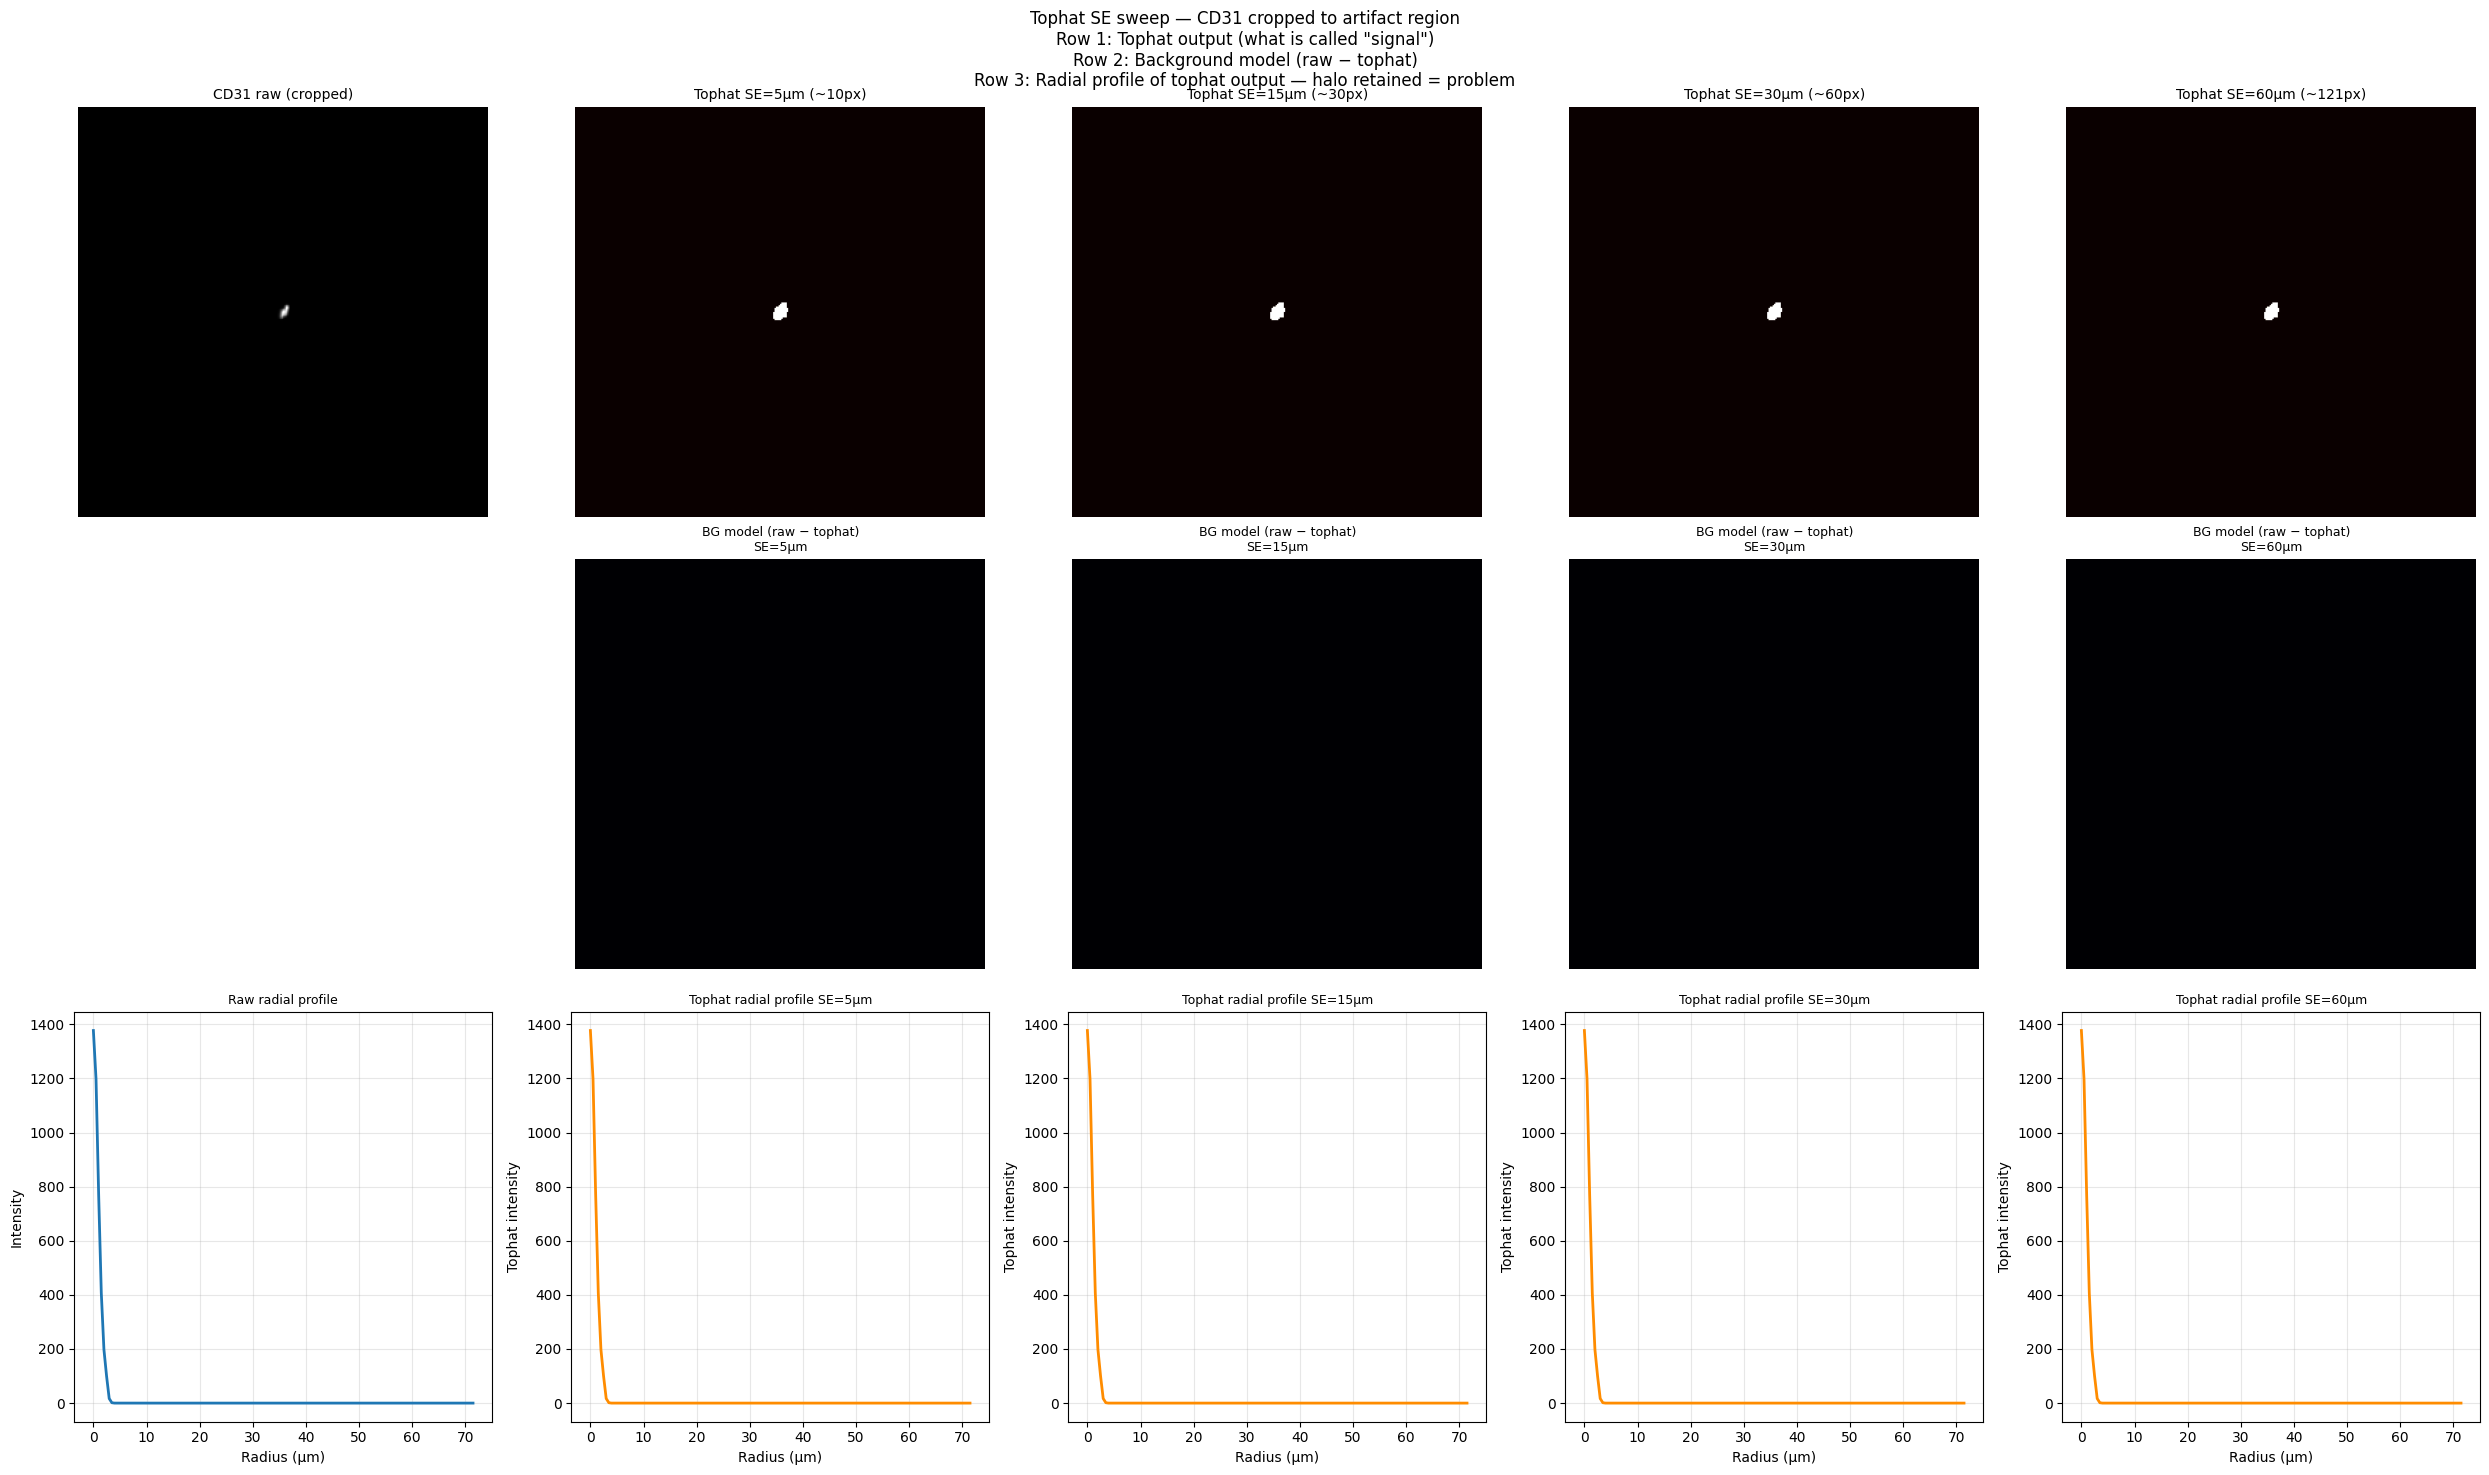

In [29]:
# ─────────────────────────────────────────────────────────────────
# 5. 2-D SPATIAL DECOMPOSITION — what tophat actually does to the halo
# ─────────────────────────────────────────────────────────────────
# Tophat(r) removes structures smaller than the SE radius r.
# If the artifact has a halo, tophat with a small SE captures only the
# bright core, leaving the halo behind as 'tissue signal'.
# With a large SE, the halo itself is also captured — but so are real
# structures like blood vessels (CD31). This cell shows all three regimes.

SE_SIZES_UM = [5, 15, 30, 60]   # µm — change as needed

crop_cd31 = chans[CD31_IDX][r0:r1, c0:c1]
crop_u16  = (crop_cd31 / max(crop_cd31.max(), 1) * 65535).astype(np.uint16)

n_se = len(SE_SIZES_UM)
fig, axes = plt.subplots(3, n_se + 1, figsize=(5*(n_se+1), 15))

# Column 0: raw crop + radial profile on same image
axes[0, 0].imshow(stretch(crop_cd31), cmap='gray')
axes[0, 0].set_title('CD31 raw (cropped)', fontsize=10)
axes[0, 0].axis('off')
axes[1, 0].axis('off')

# Radial profile of raw
radii, means, stds, _ = radial_profile(crop_cd31,
                                        ar - r0, ac - c0,
                                        max_r=CROP_HALF - 5)
axes[2, 0].plot(radii * PIXEL_UM, means, lw=2)
axes[2, 0].set_xlabel('Radius (µm)')
axes[2, 0].set_ylabel('Intensity')
axes[2, 0].set_title('Raw radial profile', fontsize=9)
axes[2, 0].grid(alpha=0.3)

tophat_vmax = None

for j, se_um in enumerate(SE_SIZES_UM):
    se_px  = max(3, round(se_um / PIXEL_UM))
    se_cv  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*se_px+1, 2*se_px+1))
    th_u16 = cv2.morphologyEx(crop_u16, cv2.MORPH_TOPHAT, se_cv,
                               borderType=cv2.BORDER_REFLECT)
    th     = th_u16.astype(np.float32) / 65535 * crop_cd31.max()
    
    if tophat_vmax is None:
        tophat_vmax = np.percentile(th, 99.5) or 1

    # Row 0: tophat result
    axes[0, j+1].imshow(th, cmap='hot', vmax=tophat_vmax)
    axes[0, j+1].set_title(f'Tophat SE={se_um}µm (~{se_px}px)', fontsize=10)
    axes[0, j+1].axis('off')
    
    # Row 1: what was REMOVED (raw - tophat = background model)
    bg_model = crop_cd31.astype(np.float32) - th
    axes[1, j+1].imshow(np.clip(bg_model, 0, None), cmap='inferno',
                         vmax=np.percentile(bg_model.clip(0), 99))
    axes[1, j+1].set_title(f'BG model (raw − tophat)\nSE={se_um}µm', fontsize=9)
    axes[1, j+1].axis('off')
    
    # Row 2: radial profile of the tophat output
    radii_th, means_th, _, _ = radial_profile(th, ar - r0, ac - c0,
                                               max_r=CROP_HALF - 5)
    axes[2, j+1].plot(radii_th * PIXEL_UM, means_th, lw=2, color='darkorange')
    axes[2, j+1].set_xlabel('Radius (µm)')
    axes[2, j+1].set_ylabel('Tophat intensity')
    axes[2, j+1].set_title(f'Tophat radial profile SE={se_um}µm', fontsize=9)
    axes[2, j+1].grid(alpha=0.3)

fig.suptitle(
    'Tophat SE sweep — CD31 cropped to artifact region\n'
    'Row 1: Tophat output (what is called "signal")\n'
    'Row 2: Background model (raw − tophat)\n'
    'Row 3: Radial profile of tophat output — halo retained = problem',
    fontsize=12
)
plt.tight_layout()
plt.show()

Computing local Z-score...
Computing DoG...
Computing LoG...
Done.


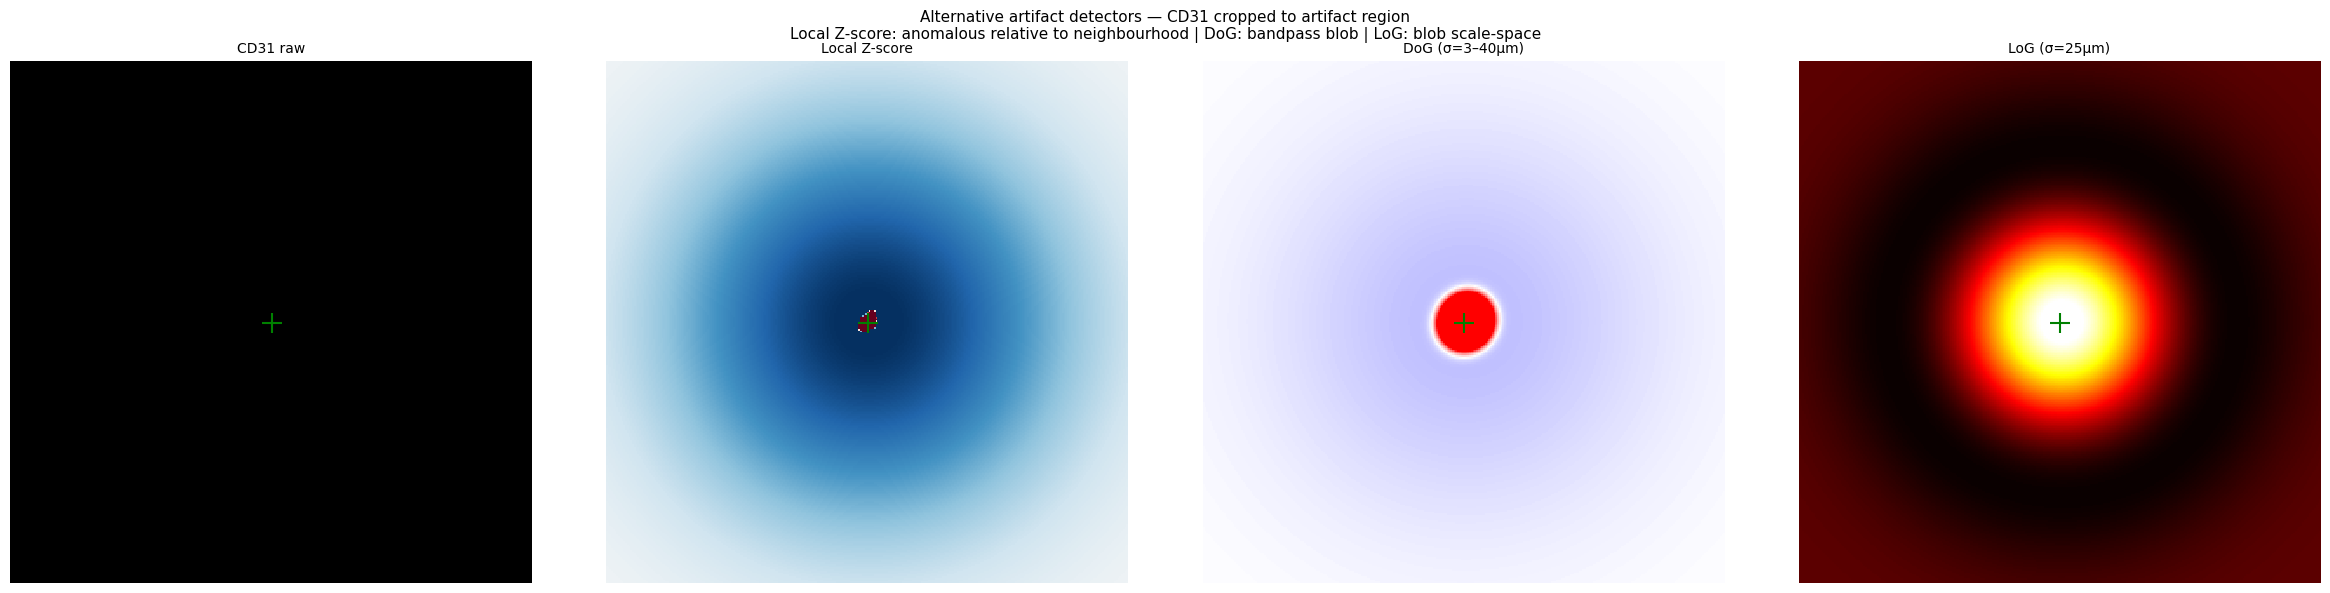

In [30]:
# ─────────────────────────────────────────────────────────────────
# 6. ALTERNATIVE DETECTION STRATEGIES — side-by-side comparison
# ─────────────────────────────────────────────────────────────────
# Four methods that can handle halos, compared head-to-head:
#
# A) Local Z-score (local mean + std normalization)
#    — normalizes each pixel relative to its neighbourhood
#    — halo core and halo ring both appear as anomalously bright/dark
#    — works when the artifact has ANY unusual local statistics
#
# B) Difference-of-Gaussians (DoG)
#    — bandpass filter: captures structures between two scale bounds
#    — halo has energy at a specific spatial frequency; DoG can isolate it
#    — tune sigma_low (core size) and sigma_high (halo outer radius)
#
# C) Laplacian of Gaussian (LoG) / blob detector
#    — classic blob detector, responds to circular bright regions
#    — will respond at the scale matching the halo outer radius
#
# D) DAPI-mask cross-channel consistency
#    — the DAPI tophat already correctly masks the artifact
#    — propagate that mask (dilated) to suppress corresponding regions
#      in all other channels — no tuning needed, uses existing signal
#    — works only because the artifact co-localizes across channels

def local_zscore_map(img, radius_px=50):
    """Z-score of each pixel relative to a local neighbourhood."""
    img_f = img.astype(np.float32)
    sigma  = radius_px / 2.0
    from scipy.ndimage import gaussian_filter
    local_mean = gaussian_filter(img_f, sigma=sigma)
    local_sq   = gaussian_filter(img_f**2, sigma=sigma)
    local_var  = np.maximum(local_sq - local_mean**2, 0)
    local_std  = np.sqrt(local_var) + 1e-6
    return (img_f - local_mean) / local_std

def dog_filter(img, sigma_low_um=3, sigma_high_um=25):
    """Difference of Gaussians — bandpass blob detector."""
    from scipy.ndimage import gaussian_filter
    s_lo = sigma_low_um  / PIXEL_UM
    s_hi = sigma_high_um / PIXEL_UM
    g_lo = gaussian_filter(img.astype(np.float32), sigma=s_lo)
    g_hi = gaussian_filter(img.astype(np.float32), sigma=s_hi)
    return g_lo - g_hi

def log_filter(img, sigma_um=15):
    """Laplacian of Gaussian — returns negative values at bright blobs."""
    from scipy.ndimage import gaussian_laplace
    sigma_px = sigma_um / PIXEL_UM
    return -gaussian_laplace(img.astype(np.float32), sigma=sigma_px)

# ── Compute all four on CD31 ──────────────────────────────────────
cd31_full  = chans[CD31_IDX]

RADIUS_NEIGHBOURHOOD_UM = 60    # local Z-score neighbourhood
DOG_SIGMA_LOW_UM        = 3     # matches nucleus-scale foreground
DOG_SIGMA_HIGH_UM       = 40    # matches expected halo outer radius
LOG_SIGMA_UM            = 25    # ≈ halo outer radius

print('Computing local Z-score...')
lz = local_zscore_map(cd31_full, radius_px=int(RADIUS_NEIGHBOURHOOD_UM / PIXEL_UM))
print('Computing DoG...')
dog = dog_filter(cd31_full, DOG_SIGMA_LOW_UM, DOG_SIGMA_HIGH_UM)
print('Computing LoG...')
log = log_filter(cd31_full, LOG_SIGMA_UM)
print('Done.')

# ── Crop to artifact region ───────────────────────────────────────
crops = {
    'CD31 raw'      : chans[CD31_IDX][r0:r1, c0:c1],
    'Local Z-score' : lz[r0:r1, c0:c1],
    f'DoG (σ={DOG_SIGMA_LOW_UM}–{DOG_SIGMA_HIGH_UM}µm)': dog[r0:r1, c0:c1],
    f'LoG (σ={LOG_SIGMA_UM}µm)': log[r0:r1, c0:c1],
}

fig, axes = plt.subplots(1, len(crops), figsize=(6*len(crops), 6))
cmaps = ['gray', 'RdBu_r', 'bwr', 'hot']
for ax, (title, crop), cmap in zip(axes, crops.items(), cmaps):
    vabs = np.percentile(np.abs(crop), 99)
    if cmap in ('RdBu_r', 'bwr'):
        ax.imshow(crop, cmap=cmap, vmin=-vabs, vmax=vabs, interpolation='nearest')
    else:
        ax.imshow(crop, cmap=cmap, vmax=np.percentile(crop, 99.5), interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.plot(ac - c0, ar - r0, 'g+', markersize=14, markeredgewidth=1.5)
    ax.axis('off')

fig.suptitle(
    'Alternative artifact detectors — CD31 cropped to artifact region\n'
    'Local Z-score: anomalous relative to neighbourhood | '
    'DoG: bandpass blob | LoG: blob scale-space',
    fontsize=11
)
plt.tight_layout()
plt.show()

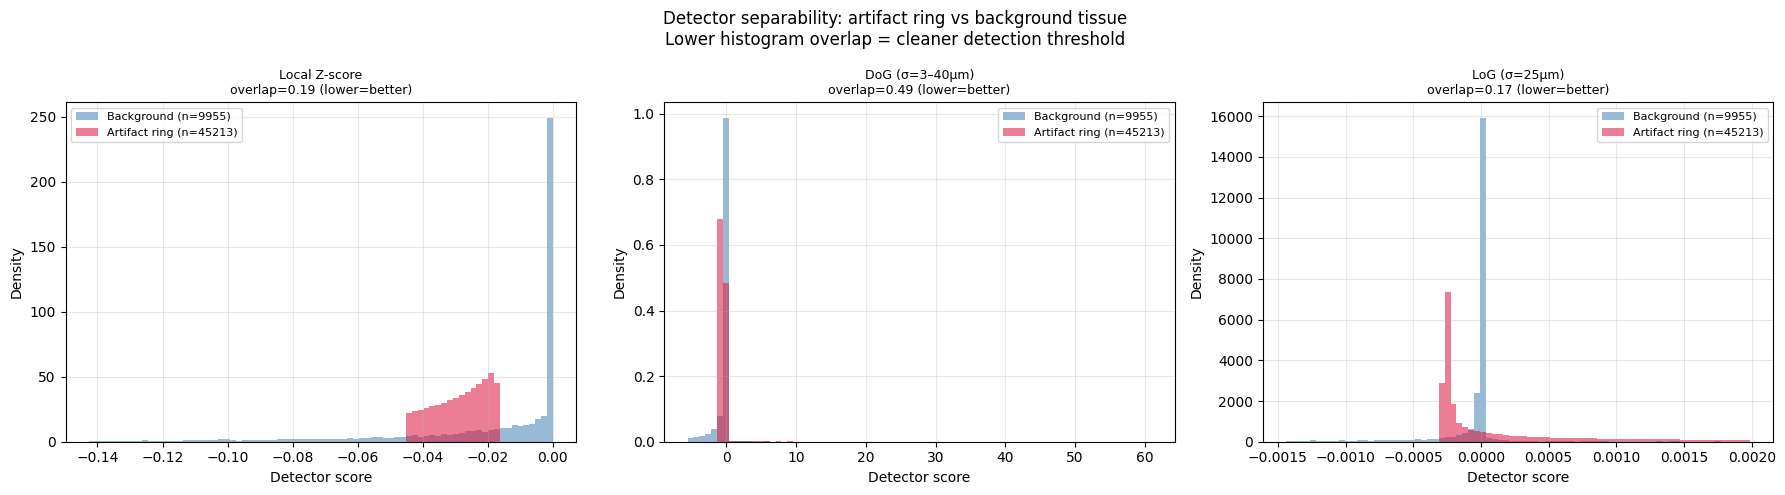

In [31]:
# ─────────────────────────────────────────────────────────────────
# 6b. THRESHOLD SENSITIVITY — which detector gives cleanest separation?
# ─────────────────────────────────────────────────────────────────
# For each detector, plot the distribution of scores at:
#   - pixels inside a ring around the artifact centre
#   - pixels in a random sample of background tissue
# A good detector shows clearly separated distributions.

def ring_pixels(img, centre_r, centre_c, r_inner, r_outer):
    Y, X = np.ogrid[:img.shape[0], :img.shape[1]]
    dist = np.sqrt((Y - centre_r)**2 + (X - centre_c)**2)
    mask = (dist >= r_inner) & (dist < r_outer)
    return img[mask]

ARTIFACT_INNER_UM = 0
ARTIFACT_OUTER_UM = 60   # expected to fully contain the artifact + halo

inner_px = int(ARTIFACT_INNER_UM / PIXEL_UM)
outer_px = int(ARTIFACT_OUTER_UM / PIXEL_UM)

detectors = {
    'Local Z-score' : lz,
    f'DoG (σ={DOG_SIGMA_LOW_UM}–{DOG_SIGMA_HIGH_UM}µm)': dog,
    f'LoG (σ={LOG_SIGMA_UM}µm)': log,
}

# Background: random pixels far from the artifact
rng  = np.random.default_rng(42)
bg_r = rng.integers(outer_px, H - outer_px, size=10_000)
bg_c = rng.integers(outer_px, W - outer_px, size=10_000)
# Keep only those far from the artifact
dist_from_art = np.sqrt((bg_r - ar)**2 + (bg_c - ac)**2)
bg_keep = dist_from_art > outer_px * 2
bg_r, bg_c = bg_r[bg_keep], bg_c[bg_keep]

fig, axes = plt.subplots(1, len(detectors), figsize=(6*len(detectors), 5))

for ax, (name, det) in zip(axes, detectors.items()):
    art_vals = ring_pixels(det, ar, ac, inner_px, outer_px)
    bg_vals  = det[bg_r, bg_c]
    
    lo  = np.percentile(np.concatenate([art_vals, bg_vals]), 0.5)
    hi  = np.percentile(np.concatenate([art_vals, bg_vals]), 99.5)
    bins = np.linspace(lo, hi, 80)
    
    ax.hist(bg_vals,  bins=bins, alpha=0.55, color='steelblue',  label=f'Background (n={len(bg_vals)})', density=True)
    ax.hist(art_vals, bins=bins, alpha=0.55, color='crimson',    label=f'Artifact ring (n={len(art_vals)})', density=True)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Detector score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # Overlap coefficient as a quick separability metric
    h_bg,  _ = np.histogram(bg_vals,  bins=bins, density=True)
    h_art, _ = np.histogram(art_vals, bins=bins, density=True)
    overlap = np.minimum(h_bg, h_art).sum() * (bins[1] - bins[0])
    ax.set_title(f'{name}\noverlap={overlap:.2f} (lower=better)', fontsize=9)

fig.suptitle(
    'Detector separability: artifact ring vs background tissue\n'
    'Lower histogram overlap = cleaner detection threshold',
    fontsize=12
)
plt.tight_layout()
plt.show()

DAPI dust mask: 10169 px, 0.0025 mm²
Artifact covered by DAPI mask: False (centre pixel)


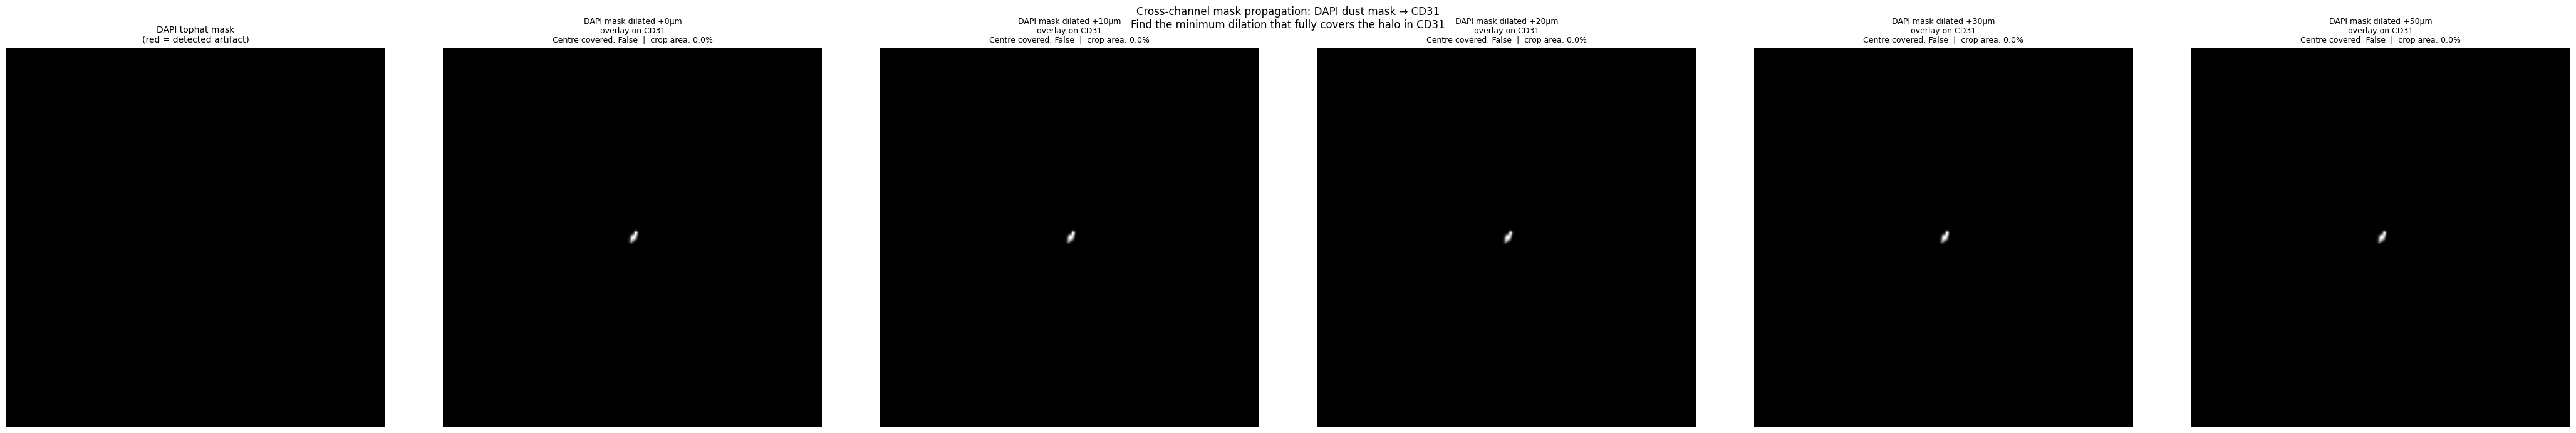

In [32]:
# ─────────────────────────────────────────────────────────────────
# 7. DAPI MASK PROPAGATION STRATEGY
# ─────────────────────────────────────────────────────────────────
# The DAPI tophat already correctly finds this artifact.
# Key question: does the DAPI artifact mask (dilated by halo radius)
# adequately cover the artifact extent in CD31?
# This tests the cross-channel propagation approach.

# Simulate the DAPI tophat detection (same params as denoise_volume.py)
DAPI_IDX         = 0
DAPI_SE_UM       = 8         # SE used in your DAPI denoise pipeline
DAPI_DUST_PCT    = 99        # percentile threshold
DAPI_MIN_AREA_PX = 50        # min blob area to call dust

dapi = chans[DAPI_IDX]
dapi_u16 = (dapi / max(dapi.max(), 1) * 65535).astype(np.uint16)
se_dapi  = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (2*int(DAPI_SE_UM/PIXEL_UM)+1, 2*int(DAPI_SE_UM/PIXEL_UM)+1)
)
dapi_th_u16 = cv2.morphologyEx(dapi_u16, cv2.MORPH_TOPHAT, se_dapi,
                                borderType=cv2.BORDER_REFLECT)
dapi_th = dapi_th_u16.astype(np.float32) / 65535 * dapi.max()

# DAPI dust mask (replicate denoise_volume.py logic)
pos_px = dapi_th_u16[dapi_th_u16 > 0]
if pos_px.size > 0:
    bright_t = int(np.percentile(pos_px, DAPI_DUST_PCT))
    bright_bin = (dapi_th_u16 >= bright_t).astype(np.uint8)
    n_lab, lab_img, stats, _ = cv2.connectedComponentsWithStats(bright_bin, connectivity=8)
    large_ids = np.where(stats[1:, cv2.CC_STAT_AREA] >= DAPI_MIN_AREA_PX)[0] + 1
    dapi_dust_mask = np.isin(lab_img, large_ids)
else:
    dapi_dust_mask = np.zeros_like(dapi, dtype=bool)

print(f'DAPI dust mask: {dapi_dust_mask.sum()} px, '
      f'{dapi_dust_mask.sum()*PIXEL_UM**2/1e6:.4f} mm²')
print(f'Artifact covered by DAPI mask: '
      f'{dapi_dust_mask[ar, ac]} (centre pixel)')

# Dilate DAPI mask by different amounts and check CD31 coverage
DILATION_SIZES_UM = [0, 10, 20, 30, 50]

fig, axes = plt.subplots(1, len(DILATION_SIZES_UM) + 1, figsize=(7*(len(DILATION_SIZES_UM)+1), 7))

# Col 0: DAPI reference
ax = axes[0]
crop_dapi = dapi[r0:r1, c0:c1]
ax.imshow(stretch(crop_dapi), cmap='gray')
dapi_mask_crop = dapi_dust_mask[r0:r1, c0:c1]
ax.imshow(np.ma.masked_where(~dapi_mask_crop, np.ones_like(dapi_mask_crop)),
          cmap='Reds', alpha=0.5, vmin=0, vmax=1)
ax.set_title('DAPI tophat mask\n(red = detected artifact)', fontsize=10)
ax.axis('off')

cd31_crop = chans[CD31_IDX][r0:r1, c0:c1]

for j, dil_um in enumerate(DILATION_SIZES_UM):
    if dil_um > 0:
        dil_px  = int(dil_um / PIXEL_UM)
        dil_se  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*dil_px+1, 2*dil_px+1))
        dil_mask = cv2.dilate(dapi_dust_mask.astype(np.uint8), dil_se).astype(bool)
    else:
        dil_mask = dapi_dust_mask.copy()

    dil_crop = dil_mask[r0:r1, c0:c1]

    ax = axes[j + 1]
    ax.imshow(stretch(cd31_crop), cmap='gray')
    ax.imshow(np.ma.masked_where(~dil_crop, np.ones_like(dil_crop)),
              cmap='Reds', alpha=0.5, vmin=0, vmax=1)
    
    # Check if the known halo outer radius is covered
    # (use the radial profile stats from cell 4)
    coverage_at_centre = dil_mask[ar, ac]
    pct_covered = dil_mask[r0:r1, c0:c1].mean() * 100
    ax.set_title(f'DAPI mask dilated +{dil_um}µm\noverlay on CD31\n'
                 f'Centre covered: {coverage_at_centre}  |  crop area: {pct_covered:.1f}%',
                 fontsize=9)
    ax.axis('off')

fig.suptitle(
    'Cross-channel mask propagation: DAPI dust mask → CD31\n'
    'Find the minimum dilation that fully covers the halo in CD31',
    fontsize=12
)
plt.tight_layout()
plt.show()

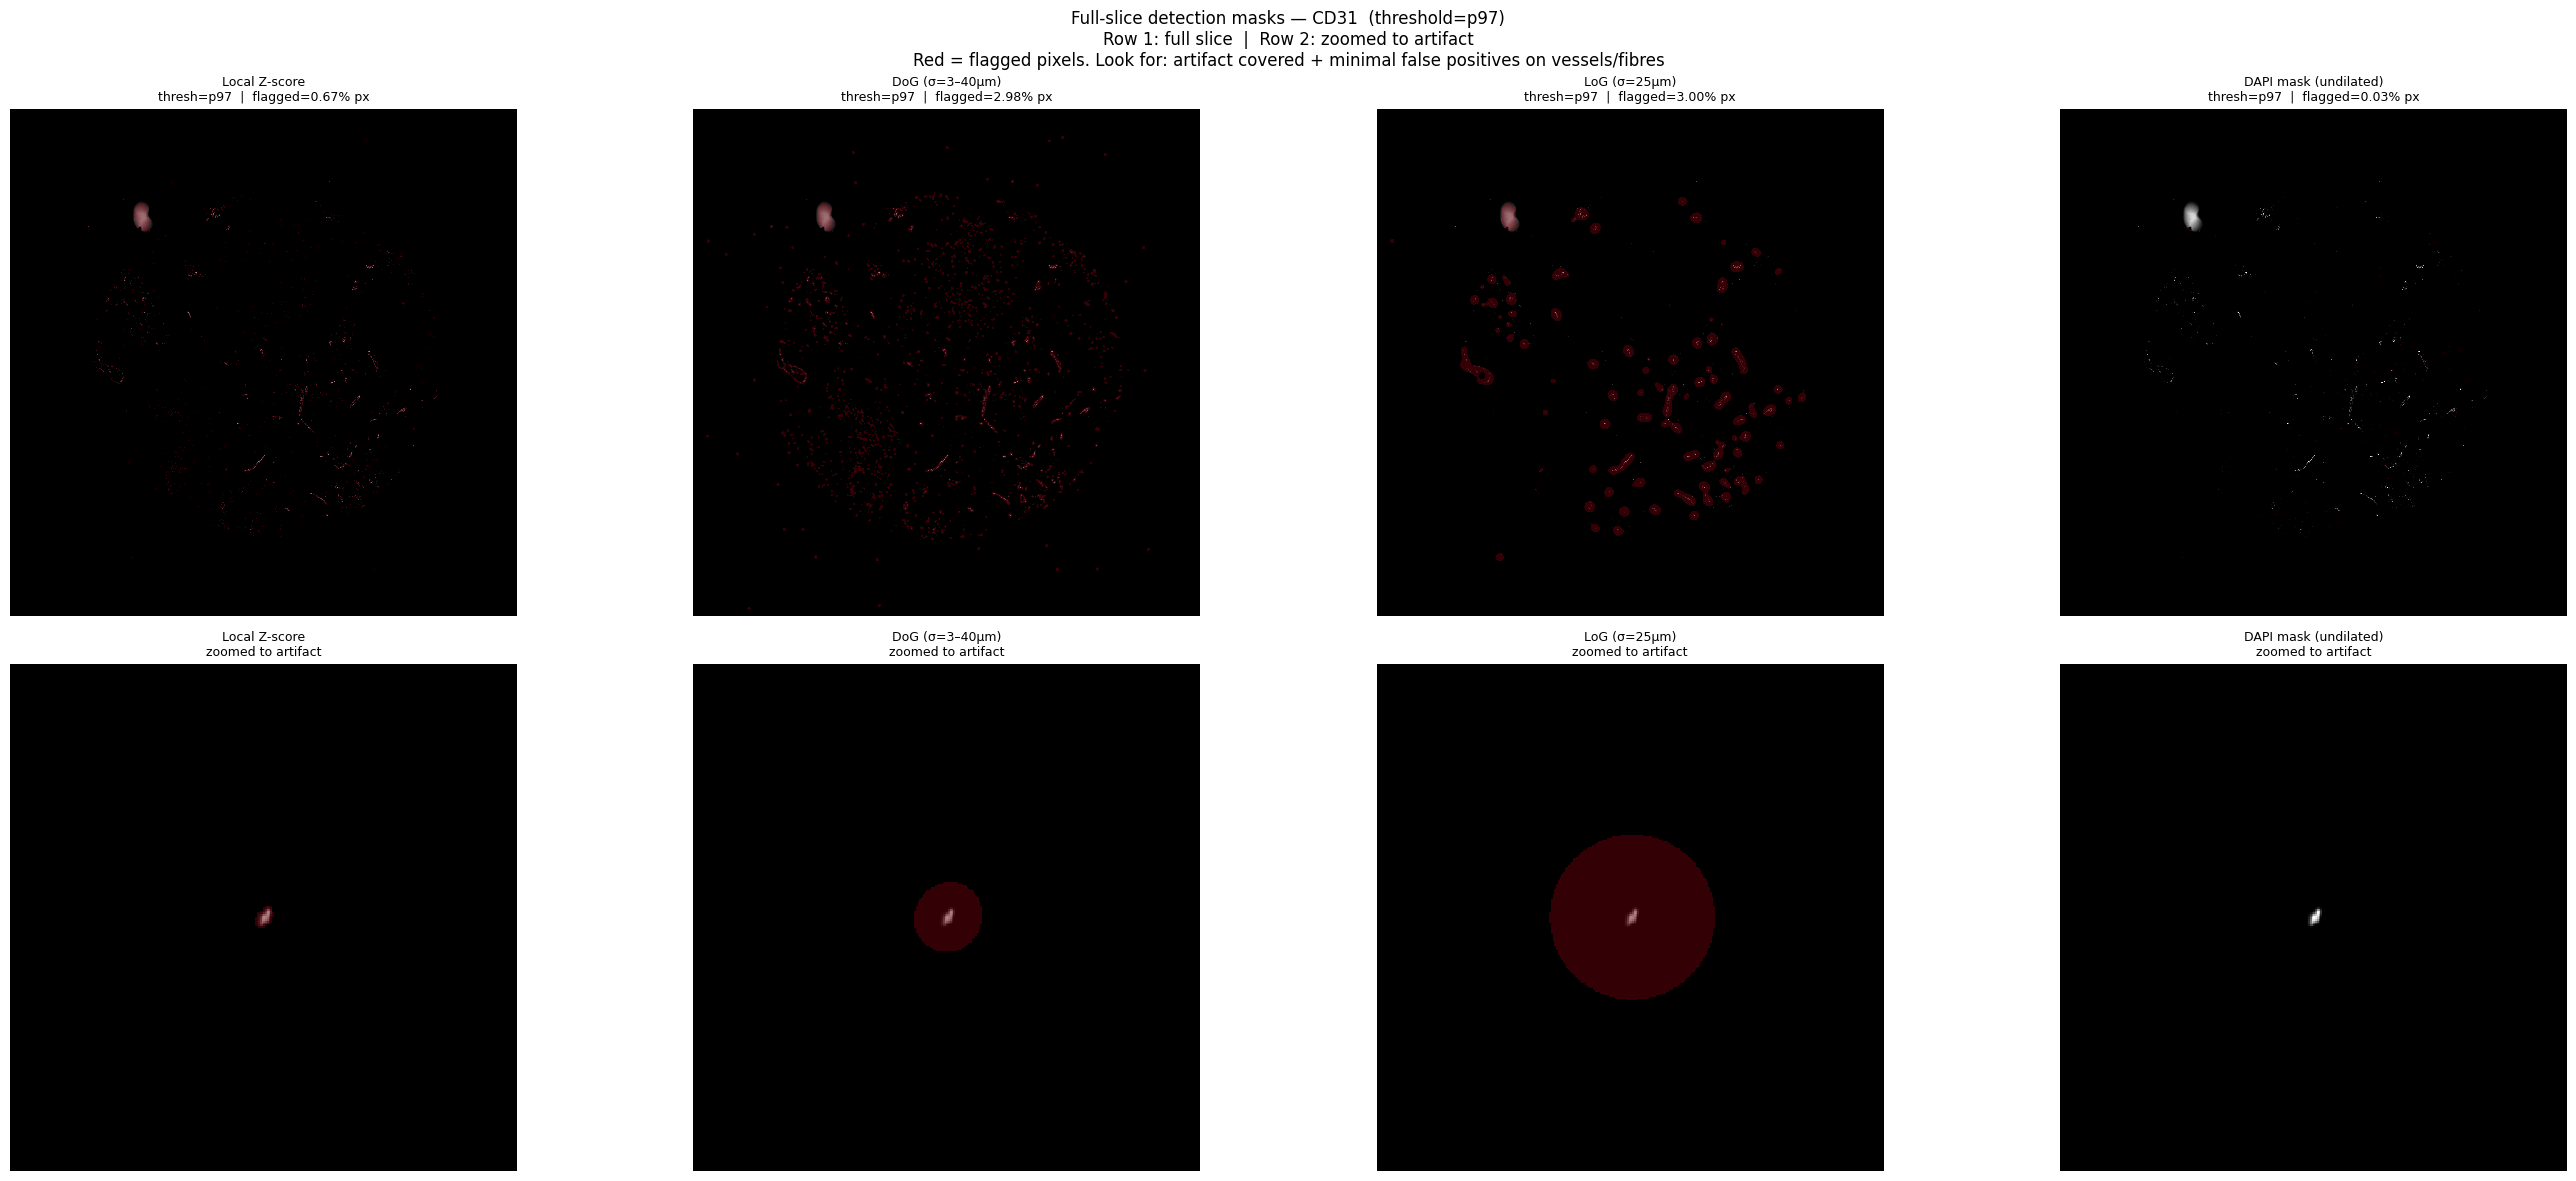

Summary:
  Local Z-score                           :  248,747 px flagged  (0.666%)
  DoG (σ=3–40µm)                          : 1,113,689 px flagged  (2.981%)
  LoG (σ=25µm)                            : 1,120,697 px flagged  (3.000%)
  DAPI mask (undilated)                   :   10,169 px flagged  (0.027%)


In [33]:
# ─────────────────────────────────────────────────────────────────
# 8. FULL-SLICE DETECTOR COMPARISON — false positive check
# ─────────────────────────────────────────────────────────────────
# A detector that perfectly isolates the artifact at the crop level
# may still produce false positives across the full tissue slice.
# This cell shows the full-slice detection mask for each method
# so you can assess false positive rates before committing to one.

# ── Threshold each detector at a given score percentile ──────────
# Adjust THRESHOLD_PCT so the artifact is covered but tissue is not.
THRESHOLD_PCT = 97   # percentile of the detector score across the full slice

detectors_full = {
    'Local Z-score' : lz,
    f'DoG (σ={DOG_SIGMA_LOW_UM}–{DOG_SIGMA_HIGH_UM}µm)': dog,
    f'LoG (σ={LOG_SIGMA_UM}µm)': log,
    'DAPI mask (undilated)': dapi_dust_mask.astype(np.float32),
}

fig, axes = plt.subplots(2, len(detectors_full), figsize=(7*len(detectors_full), 12))

for j, (name, det) in enumerate(detectors_full.items()):
    if name == 'DAPI mask (undilated)':
        binary_mask = det.astype(bool)
        threshold   = 0.5
    else:
        threshold     = np.percentile(det, THRESHOLD_PCT)
        binary_mask   = det > threshold

    n_px = binary_mask.sum()
    pct  = 100 * n_px / binary_mask.size

    # Row 0: full slice overlay on CD31
    ax0 = axes[0, j]
    ax0.imshow(stretch(cd31_full), cmap='gray', interpolation='nearest')
    ax0.imshow(np.ma.masked_where(~binary_mask, np.ones_like(binary_mask)),
               cmap='Reds', alpha=0.5, vmin=0, vmax=1, interpolation='nearest')
    ax0.set_title(f'{name}\nthresh=p{THRESHOLD_PCT}  |  flagged={pct:.2f}% px',
                  fontsize=9)
    ax0.axis('off')

    # Row 1: zoom to artifact region
    ax1 = axes[1, j]
    ax1.imshow(stretch(cd31_crop), cmap='gray', interpolation='nearest')
    mask_crop = binary_mask[r0:r1, c0:c1]
    ax1.imshow(np.ma.masked_where(~mask_crop, np.ones_like(mask_crop)),
               cmap='Reds', alpha=0.5, vmin=0, vmax=1, interpolation='nearest')
    ax1.set_title(f'{name}\nzoomed to artifact', fontsize=9)
    ax1.axis('off')

fig.suptitle(
    f'Full-slice detection masks — CD31  (threshold=p{THRESHOLD_PCT})\n'
    'Row 1: full slice  |  Row 2: zoomed to artifact\n'
    'Red = flagged pixels. Look for: artifact covered + minimal false positives on vessels/fibres',
    fontsize=12
)
plt.tight_layout()
plt.show()

print('Summary:')
for name, det in detectors_full.items():
    if name == 'DAPI mask (undilated)':
        mask = det.astype(bool)
        t    = '—'
    else:
        t    = np.percentile(det, THRESHOLD_PCT)
        mask = det > t
    print(f'  {name:40s}: {mask.sum():>8,} px flagged  ({100*mask.mean():.3f}%)')

Area gate: 203–6094 px  (50–1500 µm²)
Threshold: p97.0 = 0.000
Binary foreground: 1,113,689 px before shape filtering
Raw connected components: 1278
Blobs with area >= 5px: 1274
After shape filter: 891 blobs kept, 383 rejected

Nearest blob to known artifact centre (row=5401, col=1478):
  centroid : row=5400, col=1479  (dist=2px)
  area     : 1308.0 px  (322 µm²)
  circ     : 0.932  (need >= 0.6)
  solidity : 0.977  (need >= 0.8)
  ecc      : 0.347
  → KEPT ✓


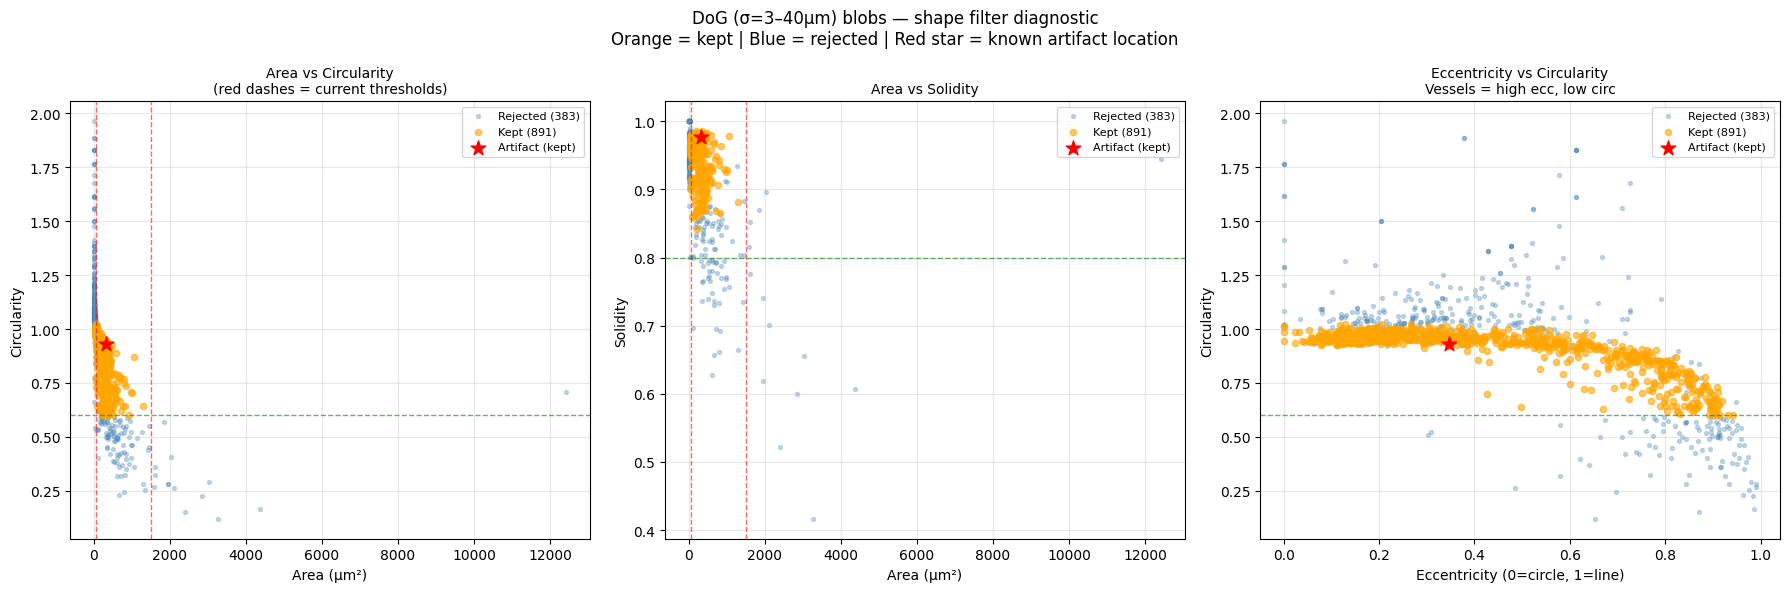

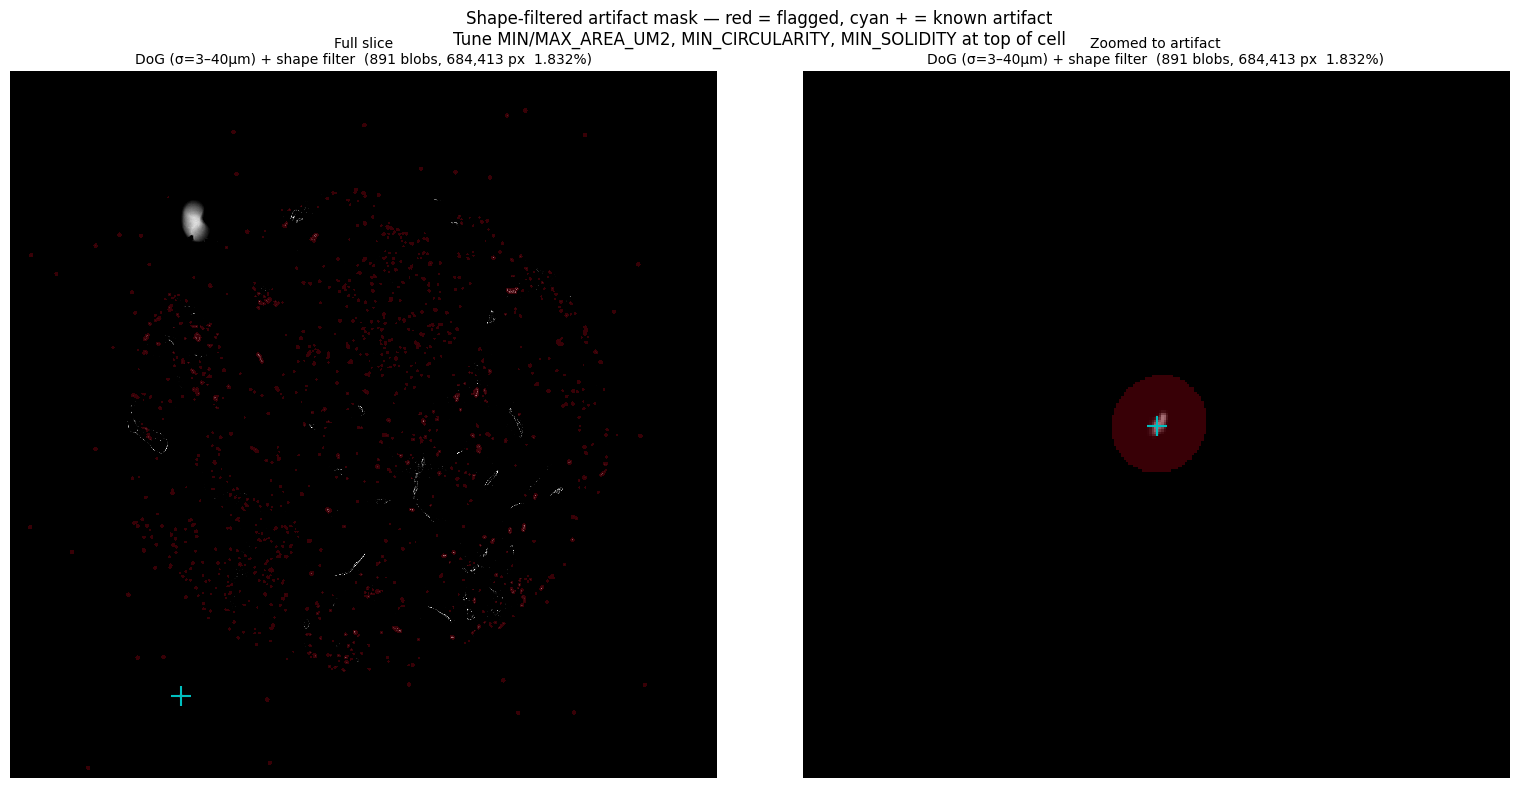


Top kept blobs by detector response:
    row   col   area_um2    circ   solid     ecc     resp
   1898  4341       1295   0.641   0.881   0.852  109.621
   3949  4441        659   0.774   0.970   0.863   99.966
   4160  3835        351   0.906   0.977   0.592   94.481
   4191  3753        410   0.894   0.975   0.583   94.423
   2479  2162        921   0.603   0.930   0.943   82.912
   4895  3824        399   0.913   0.979   0.587   82.684
   2780  4027       1009   0.704   0.928   0.751   75.795
   2820  3862        810   0.750   0.935   0.737   71.477
   4852  2983        420   0.907   0.973   0.416   70.112
   3797  2753        596   0.891   0.980   0.614   64.770
   4828  3347        859   0.735   0.964   0.879   63.359
   3384  3438        337   0.845   0.949   0.431   62.560
   3792  3473        397   0.878   0.976   0.694   61.514
   3032  3574        475   0.712   0.915   0.773   61.084
   2300  1620       1060   0.869   0.979   0.617   60.035
   1441  2629        981   0.710  

In [34]:
# ─────────────────────────────────────────────────────────────────
# 8b. SHAPE + AREA FILTERED DETECTION
# ─────────────────────────────────────────────────────────────────
# The p99.5 global threshold catches the tissue edge (large, irregular)
# as well as the artifact (small, compact, circular). A global percentile
# alone can never separate them because it has no spatial context.
#
# Strategy:
#   1. Apply DoG or LoG to get a blob-response map
#   2. Use a LOW threshold (e.g. p98 of non-zero tissue px) so we
#      over-detect — the artifact is included with many false positives
#   3. Label connected components and compute per-blob shape features:
#        area_px       — blob size in pixels
#        circularity   — 4π·area / perimeter²  (1.0 = perfect circle)
#        eccentricity  — 0.0 = circle, 1.0 = line
#        solidity      — area / convex_hull_area (1.0 = convex)
#        mean_response — mean DoG/LoG score inside the blob
#   4. Keep only blobs that pass ALL of:
#        area_px       in [MIN_AREA_PX, MAX_AREA_PX]
#        circularity   >= MIN_CIRC
#        solidity      >= MIN_SOLID
#   5. Inspect the scatter plots — the artifact should cluster away
#      from vessel/fibre structures which are elongated (low circularity)
#      and away from tissue edge which is huge (high area)
#
# Tune the four sliders at the top of this cell.
# ─────────────────────────────────────────────────────────────────

# ── Tunable parameters ────────────────────────────────────────────
DETECTOR          = 'DoG'       # 'DoG' or 'LoG'
THRESHOLD_PCT     = 97.0       # Global percentile (matches Section 8 logic)

MIN_AREA_UM2      = 50          # minimum blob area in µm²
MAX_AREA_UM2      = 1500        # Reduced from 15_000 to reject tissue

# Demand higher symmetry to reject irregular tissue borders
MIN_CIRCULARITY   = 0.60        # Raised from 0.35
MIN_SOLIDITY      = 0.80        # Raised from 0.55

# Convert area thresholds to pixels
MIN_AREA_PX = int(MIN_AREA_UM2  / PIXEL_UM**2)
MAX_AREA_PX = int(MAX_AREA_UM2  / PIXEL_UM**2)

print(f'Area gate: {MIN_AREA_PX}–{MAX_AREA_PX} px  '
      f'({MIN_AREA_UM2}–{MAX_AREA_UM2} µm²)')

# ── Pick the detector map ─────────────────────────────────────────
if DETECTOR == 'DoG':
    det_map = dog    
    det_label = f'DoG (σ={DOG_SIGMA_LOW_UM}–{DOG_SIGMA_HIGH_UM}µm)'
else:
    det_map = log    
    det_label = f'LoG (σ={LOG_SIGMA_UM}µm)'

# ── Apply global threshold (Matching Section 8) ───────────────────
thresh_val = np.percentile(det_map, THRESHOLD_PCT)
binary = (det_map > thresh_val).astype(np.uint8)

# Suppress image border
margin = 50
binary[:margin, :] = 0; binary[-margin:, :] = 0
binary[:, :margin] = 0; binary[:, -margin:] = 0

print(f'Threshold: p{THRESHOLD_PCT} = {thresh_val:.3f}')
print(f'Binary foreground: {binary.sum():,} px before shape filtering')



# ── Connected components + shape features ─────────────────────────
n_lab, lab_img, stats, centroids = cv2.connectedComponentsWithStats(
    binary, connectivity=8
)
print(f'Raw connected components: {n_lab - 1}')

from skimage.measure import regionprops

# Build a regionprops list for shape features (skimage is cleaner than cv2 here)
regions = regionprops(lab_img)

blob_records = []
for reg in regions:
    if reg.label == 0:
        continue
    area_px = reg.area
    if area_px < 5:          # skip single-pixel noise
        continue

    # Circularity = 4π·area / perimeter²  (perimeter from skimage)
    perim = reg.perimeter
    circ  = (4 * np.pi * area_px / perim**2) if perim > 0 else 0

    # Solidity = area / convex hull area
    solid = reg.solidity

    # Eccentricity (0=circle, 1=line)
    ecc   = reg.eccentricity

    # Mean detector response inside this blob
    mean_resp = float(det_map[lab_img == reg.label].mean())

    # Centroid (row, col)
    cr, cc = reg.centroid

    blob_records.append({
        'label'      : reg.label,
        'area_px'    : area_px,
        'area_um2'   : area_px * PIXEL_UM**2,
        'circ'       : circ,
        'solid'      : solid,
        'ecc'        : ecc,
        'mean_resp'  : mean_resp,
        'row'        : int(round(cr)),
        'col'        : int(round(cc)),
    })

print(f'Blobs with area >= 5px: {len(blob_records)}')

# ── Apply shape + area filter ─────────────────────────────────────
kept   = [b for b in blob_records
          if MIN_AREA_PX  <= b['area_px'] <= MAX_AREA_PX
          and b['circ']   >= MIN_CIRCULARITY
          and b['solid']  >= MIN_SOLIDITY]

rejected = [b for b in blob_records
            if not (MIN_AREA_PX  <= b['area_px'] <= MAX_AREA_PX
                    and b['circ']   >= MIN_CIRCULARITY
                    and b['solid']  >= MIN_SOLIDITY)]

print(f'After shape filter: {len(kept)} blobs kept, {len(rejected)} rejected')

# ── Which bin does the known artifact fall into? ───────────────────
# Find the blob whose centroid is closest to (ar, ac)
if blob_records:
    dists = [(abs(b['row']-ar) + abs(b['col']-ac), b) for b in blob_records]
    # Use a lambda key to strictly sort by the distance integer (index 0)
    # This prevents Python from attempting to compare dictionaries during a tie.
    dists.sort(key=lambda x: x[0])
    
    nearest = dists[0][1]
    dist_px = dists[0][0]
    in_kept = nearest in kept
    print(f'\nNearest blob to known artifact centre (row={ar}, col={ac}):')
    print(f'  centroid : row={nearest["row"]}, col={nearest["col"]}  '
          f'(dist={dist_px:.0f}px)')
    print(f'  area     : {nearest["area_px"]} px  ({nearest["area_um2"]:.0f} µm²)')
    print(f'  circ     : {nearest["circ"]:.3f}  (need >= {MIN_CIRCULARITY})')
    print(f'  solidity : {nearest["solid"]:.3f}  (need >= {MIN_SOLIDITY})')
    print(f'  ecc      : {nearest["ecc"]:.3f}')
    print(f'  → {"KEPT ✓" if in_kept else "REJECTED ✗  ← loosen a threshold"}')

# ── Scatter: area vs circularity, colour = kept/rejected/artifact ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def scatter_blobs(ax, xkey, ykey, xlabel, ylabel):
    if rejected:
        ax.scatter([b[xkey] for b in rejected],
                   [b[ykey] for b in rejected],
                   s=8, alpha=0.3, color='steelblue', label=f'Rejected ({len(rejected)})')
    if kept:
        ax.scatter([b[xkey] for b in kept],
                   [b[ykey] for b in kept],
                   s=20, alpha=0.6, color='orange', label=f'Kept ({len(kept)})')
    # Mark the known artifact
    if blob_records:
        ax.scatter(nearest[xkey], nearest[ykey],
                   s=120, color='red', zorder=5, marker='*',
                   label=f'Artifact ({"kept" if in_kept else "rejected"})')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

scatter_blobs(axes[0], 'area_um2', 'circ',
              'Area (µm²)', 'Circularity')
axes[0].axvline(MIN_AREA_UM2, color='red', ls='--', lw=1, alpha=0.6)
axes[0].axvline(MAX_AREA_UM2, color='red', ls='--', lw=1, alpha=0.6)
axes[0].axhline(MIN_CIRCULARITY, color='green', ls='--', lw=1, alpha=0.6)
axes[0].set_title('Area vs Circularity\n(red dashes = current thresholds)', fontsize=10)

scatter_blobs(axes[1], 'area_um2', 'solid',
              'Area (µm²)', 'Solidity')
axes[1].axvline(MIN_AREA_UM2, color='red', ls='--', lw=1, alpha=0.6)
axes[1].axvline(MAX_AREA_UM2, color='red', ls='--', lw=1, alpha=0.6)
axes[1].axhline(MIN_SOLIDITY, color='green', ls='--', lw=1, alpha=0.6)
axes[1].set_title('Area vs Solidity', fontsize=10)

scatter_blobs(axes[2], 'ecc', 'circ',
              'Eccentricity (0=circle, 1=line)', 'Circularity')
axes[2].axhline(MIN_CIRCULARITY, color='green', ls='--', lw=1, alpha=0.6)
axes[2].set_title('Eccentricity vs Circularity\nVessels = high ecc, low circ', fontsize=10)

fig.suptitle(
    f'{det_label} blobs — shape filter diagnostic\n'
    f'Orange = kept | Blue = rejected | Red star = known artifact location',
    fontsize=12
)
plt.tight_layout()
plt.show()

# ── Full-slice overlay with kept blobs ────────────────────────────
kept_mask = np.zeros_like(lab_img, dtype=bool)
for b in kept:
    kept_mask |= (lab_img == b['label'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (title, crop_r0, crop_r1, crop_c0, crop_c1) in zip(axes, [
    ('Full slice', 0, H, 0, W),
    ('Zoomed to artifact', r0, r1, c0, c1),
]):
    disp = cd31_full[crop_r0:crop_r1, crop_c0:crop_c1]
    mask_crop = kept_mask[crop_r0:crop_r1, crop_c0:crop_c1]
    ax.imshow(stretch(disp), cmap='gray', interpolation='nearest')
    ax.imshow(np.ma.masked_where(~mask_crop, np.ones_like(mask_crop)),
              cmap='Reds', alpha=0.55, vmin=0, vmax=1, interpolation='nearest')
    if crop_r0 == 0:   # full slice — mark artifact centre
        ax.plot(ac, ar, 'c+', markersize=14, markeredgewidth=1.5)
    else:              # zoomed — centre relative to crop
        ax.plot(ac - crop_c0, ar - crop_r0, 'c+', markersize=14, markeredgewidth=1.5)
    ax.set_title(f'{title}\n{det_label} + shape filter  '
                 f'({len(kept)} blobs, {kept_mask.sum():,} px  '
                 f'{100*kept_mask.mean():.3f}%)', fontsize=10)
    ax.axis('off')

fig.suptitle(
    'Shape-filtered artifact mask — red = flagged, cyan + = known artifact\n'
    f'Tune MIN/MAX_AREA_UM2, MIN_CIRCULARITY, MIN_SOLIDITY at top of cell',
    fontsize=12
)
plt.tight_layout()
plt.show()

# ── Per-blob summary table (top 20 kept blobs by mean response) ───
if kept:
    print(f'\nTop kept blobs by detector response:')
    print(f'  {"row":>5} {"col":>5} {"area_um2":>10} {"circ":>7} {"solid":>7} {"ecc":>7} {"resp":>8}')
    for b in sorted(kept, key=lambda x: -x['mean_resp'])[:20]:
        marker = ' ← artifact' if b is nearest else ''
        print(f'  {b["row"]:>5} {b["col"]:>5} {b["area_um2"]:>10.0f} '
              f'{b["circ"]:>7.3f} {b["solid"]:>7.3f} {b["ecc"]:>7.3f} '
              f'{b["mean_resp"]:>8.3f}{marker}')


In [35]:
# ─────────────────────────────────────────────────────────────────
# 9. SUMMARY — parameter recommendation
# ─────────────────────────────────────────────────────────────────
# After running all cells, fill in the values you observed:

print('='*60)
print('ARTIFACT CHARACTERIZATION SUMMARY')
print('='*60)

# Recompute radial stats for the summary
radii, means, stds, meds = radial_profile(chans[CD31_IDX], ar, ac, max_r=MAX_RADIUS_PX)
search_start = max(1, int(5 / PIXEL_UM))
local_min_idx = search_start + np.argmin(means[search_start:])
local_max_idx = local_min_idx + np.argmax(means[local_min_idx:])

halo_inner_um = local_min_idx * PIXEL_UM
halo_outer_um = local_max_idx * PIXEL_UM
halo_outer_px = local_max_idx

print(f'Core peak radius   : ~0–{5:.0f} µm')
print(f'Depletion ring     : {halo_inner_um:.1f} µm from centre')
print(f'Halo outer edge    : {halo_outer_um:.1f} µm from centre  ({halo_outer_px} px)')
print()
print('WHY TOPHAT FAILS:')
print(f'  SE < {halo_outer_um:.0f} µm → halo ring not captured, left as false signal')
print(f'  SE > {halo_outer_um:.0f} µm → halo captured but real vessel/fibre structure')
print(f'                     at same scale is also suppressed (false negatives)')
print()
print('RECOMMENDED NEXT STEPS (based on this analysis):')
print('  1. DAPI mask propagation: dilate the existing DAPI dust mask by')
print(f'     ~{halo_outer_um:.0f}µm and apply to all marker channels before measurement.')
print('     Advantage: zero additional tuning — reuses DAPI detection.')
print('     Test in cell 7: which dilation value fully covers the CD31 halo?')
print()
print('  2. Local Z-score threshold: flag pixels > threshold_z in the')
print('     local-z map (cell 6b histogram overlap shows best threshold).')
print('     Works independently per channel without DAPI dependency.')
print()
print('  3. DoG bandpass detector: tune sigma_high to the halo outer radius')
print(f'     ({halo_outer_um:.0f}µm) and sigma_low to the core width (~3–5µm).')
print('     Apply a minimum-area filter on connected components to avoid')
print('     calling fine vessel structures as artifacts.')
print('='*60)

ARTIFACT CHARACTERIZATION SUMMARY
Core peak radius   : ~0–5 µm
Depletion ring     : 5.0 µm from centre
Halo outer edge    : 5.0 µm from centre  (10 px)

WHY TOPHAT FAILS:
  SE < 5 µm → halo ring not captured, left as false signal
  SE > 5 µm → halo captured but real vessel/fibre structure
                     at same scale is also suppressed (false negatives)

RECOMMENDED NEXT STEPS (based on this analysis):
  1. DAPI mask propagation: dilate the existing DAPI dust mask by
     ~5µm and apply to all marker channels before measurement.
     Advantage: zero additional tuning — reuses DAPI detection.
     Test in cell 7: which dilation value fully covers the CD31 halo?

  2. Local Z-score threshold: flag pixels > threshold_z in the
     local-z map (cell 6b histogram overlap shows best threshold).
     Works independently per channel without DAPI dependency.

  3. DoG bandpass detector: tune sigma_high to the halo outer radius
     (5µm) and sigma_low to the core width (~3–5µm).
     Appl

Initializing Artifact Detection Pipeline...
1. Computing Difference of Gaussians...
2. Applying Morphological Gates...

Pipeline Complete. Kept Top 1 Targets.
  Rank 1: Center(row=1301, col=1591), Area=12050µm², Score=297.9


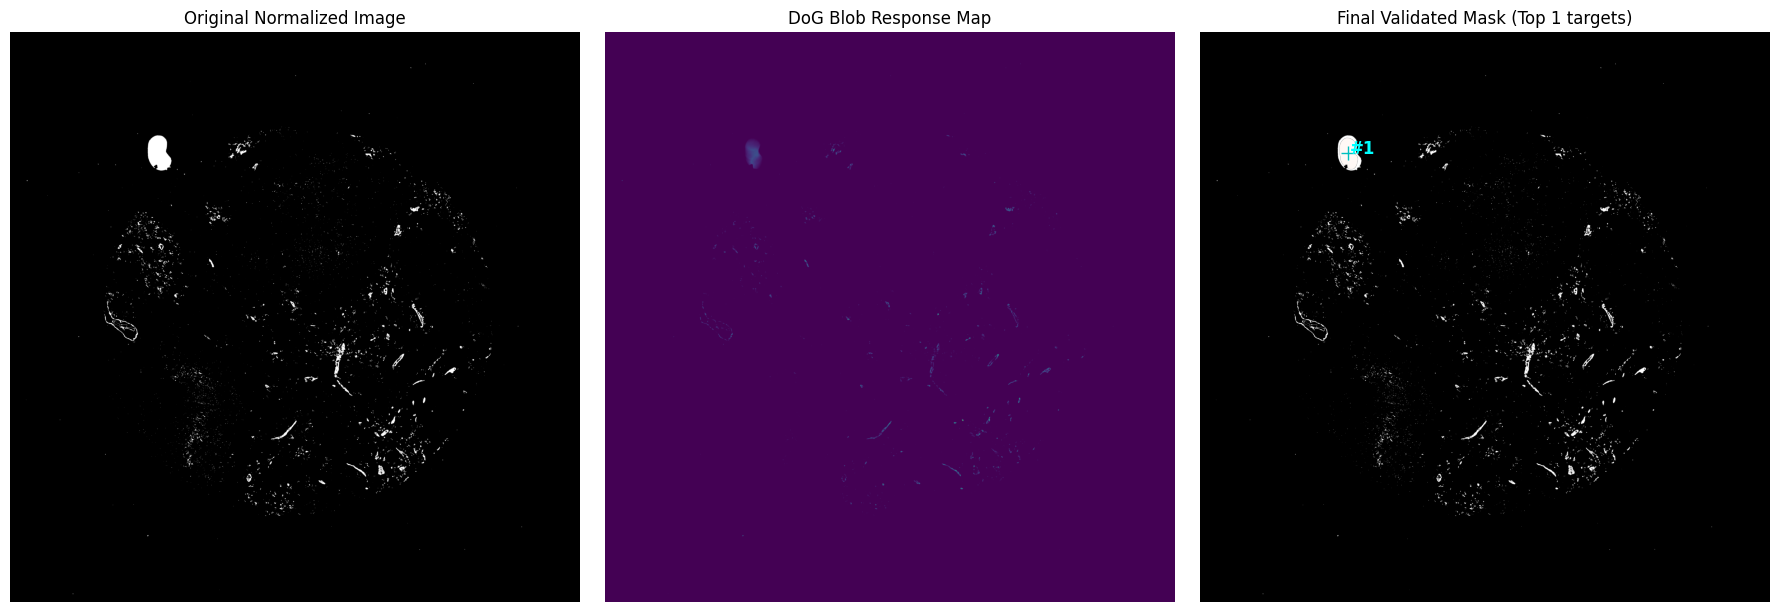

In [44]:
# =============================================================================
# ARTIFACT DETECTION MODULE
# =============================================================================
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.measure import regionprops

def compute_dog_response(image, sigma_low=2.0, sigma_high=8.0):
    """
    Applies a Difference of Gaussians (DoG) filter to isolate blob-like structures.
    
    Why: 
    Raw intensity is unreliable. DoG acts as a spatial bandpass filter. 
    It suppresses large structures (like thick vessels) and enhances structures 
    that match the spatial frequency defined by the sigma values.
    """
    # Conversion to float32 is critical to prevent uint8 underflow during subtraction
    img_f = image.astype(np.float32)
    
    blur_low = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma_low, sigmaY=sigma_low)
    blur_high = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma_high, sigmaY=sigma_high)
    
    dog_map = blur_low - blur_high
    
    # We are only interested in bright blobs on dark backgrounds
    dog_map[dog_map < 0] = 0 
    
    return dog_map

def apply_morphological_gates(dog_map, dog_threshold, min_area, max_area, min_circ, min_solid):
    """
    Extracts connected components from a thresholded map and filters them 
    based on strict geometric properties.
    
    Why:
    A low threshold generates false positives (noise, frayed edges). 
    Morphological gating mathematically enforces the expectation that 
    the target artifact is compact, isolated, and highly symmetric.
    """
    # 1. Generate permissive candidates
    binary_map = (dog_map > dog_threshold).astype(np.uint8)
    
    # 2. Group contiguous pixels into discrete blobs
    n_labels, labels = cv2.connectedComponents(binary_map, connectivity=8)
    regions = regionprops(labels)
    
    kept_mask = np.zeros_like(binary_map, dtype=bool)
    validation_stats = []
    
    # 3. Apply geometric gates
    for reg in regions:
        area = reg.area
        if not (min_area <= area <= max_area):
            continue
            
        perimeter = reg.perimeter
        if perimeter == 0:
            continue
            
        # 4*pi*area / perimeter^2 (1.0 is a perfect circle)
        circularity = (4 * np.pi * area) / (perimeter ** 2)
        if circularity < min_circ:
            continue
            
        solidity = reg.solidity
        if solidity < min_solid:
            continue
            
        # If all gates pass, add to final output
        kept_mask[labels == reg.label] = True
        validation_stats.append({
            'centroid': reg.centroid,  # (row, col)
            'area': area,
            'circularity': circularity,
            'solidity': solidity
        })
        
    return kept_mask, validation_stats

def run_artifact_pipeline(image, pixel_um):
    """
    Main execution controller with Top-N ranking and relative comparisons.
    """
    print("Initializing Artifact Detection Pipeline...")
    
   # --- 1. Tuning Parameters ---
    # Widen the bandpass window. A high sigma of 60.0 allows structures up to 
    # ~60 pixels in radius (~30 µm) to survive the background subtraction.
   # --- 1. Tuning Parameters ---
    DOG_SIGMA_LOW = 2.0
    DOG_SIGMA_HIGH = 60.0
    DOG_THRESHOLD = 1.0 
    
    # LOCK IN THE MACRO-ARTIFACT
    MIN_AREA_UM2 = 10000.0   # <-- Change this to a number just below Rank 1's area
    MAX_AREA_UM2 = 35000.0
    
    MIN_CIRCULARITY = 0.20
    MIN_SOLIDITY = 0.40
    
    min_area_px = MIN_AREA_UM2 / (pixel_um ** 2)
    max_area_px = MAX_AREA_UM2 / (pixel_um ** 2)
    
    # --- 2. Execution ---
    print("1. Computing Difference of Gaussians...")
    dog_map = compute_dog_response(image, DOG_SIGMA_LOW, DOG_SIGMA_HIGH)
    
    print("2. Applying Morphological Gates...")
    # Generate permissive candidates
    binary_map = (dog_map > DOG_THRESHOLD).astype(np.uint8)
    n_labels, labels = cv2.connectedComponents(binary_map, connectivity=8)
    regions = regionprops(labels)
    
    # Collect valid candidates and score them by their max DoG response
    valid_candidates = []
    for reg in regions:
        area = reg.area
        if not (min_area_px <= area <= max_area_px): continue
        perimeter = reg.perimeter
        if perimeter == 0: continue
        circularity = (4 * np.pi * area) / (perimeter ** 2)
        if circularity < MIN_CIRCULARITY: continue
        if reg.solidity < MIN_SOLIDITY: continue
            
        # Score the blob by the maximum DoG intensity inside it
        blob_mask = (labels == reg.label)
        max_response = dog_map[blob_mask].max()
        
        valid_candidates.append({
            'label': reg.label,
            'centroid': reg.centroid,
            'area_um2': area * (pixel_um ** 2),
            'circularity': circularity,
            'solidity': reg.solidity,
            'score': max_response
        })

    # --- 3. Top-N Ranking & Area Comparison ---
    # Sort candidates by DoG score (highest first)
    # Sort by total artifact mass (Size multiplied by Intensity)
    valid_candidates.sort(key=lambda x: x['area_um2'] * x['score'], reverse=True)
    
    # Limit to Top 3
    top_targets = valid_candidates[:3]
    
    # Build final mask for only the top targets
    final_mask = np.zeros_like(binary_map, dtype=bool)
    for target in top_targets:
        final_mask[labels == target['label']] = True

    print(f"\nPipeline Complete. Kept Top {len(top_targets)} Targets.")
    for i, s in enumerate(top_targets):
        print(f"  Rank {i+1}: Center(row={s['centroid'][0]:.0f}, col={s['centroid'][1]:.0f}), "
              f"Area={s['area_um2']:.0f}µm², Score={s['score']:.1f}")

    if len(top_targets) >= 2:
        area_diff = abs(top_targets[0]['area_um2'] - top_targets[1]['area_um2'])
        print(f"\n→ Area difference between Rank 1 and Rank 2: {area_diff:.0f} µm²")
        if top_targets[0]['area_um2'] > top_targets[1]['area_um2']:
            print("  (Rank 1 is larger)")
        else:
            print("  (Rank 2 is larger)")

    # --- 4. Diagnostics Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    disp_img = image.astype(np.float32)
    p2, p98 = np.percentile(disp_img, (2, 98))
    disp_img = np.clip((disp_img - p2) / (p98 - p2 + 1e-5), 0, 1)
    
    axes[0].imshow(disp_img, cmap='gray')
    axes[0].set_title('Original Normalized Image')
    axes[0].axis('off')
    
    axes[1].imshow(dog_map, cmap='viridis')
    axes[1].set_title('DoG Blob Response Map')
    axes[1].axis('off')
    
    axes[2].imshow(disp_img, cmap='gray')
    axes[2].imshow(np.ma.masked_where(~final_mask, final_mask), cmap='Reds', alpha=0.6)
    
    # Plot crosshairs and rank numbers on the final image
    for i, t in enumerate(top_targets):
        r, c = t['centroid']
        axes[2].plot(c, r, 'c+', markersize=10, markeredgewidth=1)
        axes[2].text(c + 15, r, f"#{i+1}", color='cyan', fontsize=12, fontweight='bold')
        
    axes[2].set_title(f'Final Validated Mask (Top {len(top_targets)} targets)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return final_mask, top_targets

# =============================================================================
# ENTRY POINT
# =============================================================================
# Replace 'cd31' and 'PIXEL_UM' with your existing notebook variables.
mask, artifact_stats = run_artifact_pipeline(image=cd31, pixel_um=PIXEL_UM)